# Multivariate Exploratory Data Analysis — `epa-full.csv`

**Input:** `data/final/epa-full.csv` — the terminal (T1) modeling table from the
merge pipeline (`MERGE.md`). One row per water-quality observation
(`MonitoringLocationIdentifier` × `ActivityStartDateTime`), joined to climate, weather,
streamflow, soil, land-cover and agricultural-context attributes.

**Scope:** *relationships between variables.* The companion notebook
[`univariate-analysis.ipynb`](univariate-analysis.ipynb) established what each variable is
on its own — units, distribution, missingness, censoring. This notebook takes those as
given and asks the next question: **how do the variables move together?**

Three relationship blocks are covered, in order:

1. **feature ↔ feature** — redundancy and the true dimensionality of the 30-column input space
2. **target ↔ target** — whether the 12 analytes are 12 independent problems or a few
3. **target ↔ feature** — which inputs actually carry signal, and how much

…and then three questions that a plain correlation matrix cannot answer, but that decide
whether any of those numbers mean anything:

4. **Is the relationship linear?** (Spearman vs. mutual information)
5. **Where does the correlation live — across stations, or across time within a station?**
6. **Is it real, or is it season?** (partial correlation holding day-of-year fixed)

**What this notebook covers**

| § | Section |
|---|---------|
| 0 | Setup, plot style, variable contract |
| 1 | Method — which coefficient, on how many rows |
| 2 | Feature ↔ feature: clustered correlation, redundant pairs, VIF, PCA, feature-space geometry |
| 3 | Target ↔ target: co-measurement, chemical families |
| 4 | Target ↔ feature: the signal matrix, strongest drivers per target |
| 5 | Linear vs. non-linear association (mutual information) |
| 6 | Between-station vs. within-station decomposition |
| 7 | Seasonal confounding (partial correlation) |
| 8 | The land-cover simplex — an exact linear dependency in the feature set |
| 9 | Findings |
| 10 | Red flags |

Summary tables are written to `src/04_eda/outputs/` with an `mv_` prefix.

## 0. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from scipy.cluster.hierarchy import dendrogram, fcluster, leaves_list, linkage
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")

# Locate the repo root from wherever the kernel was started.
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data" / "final").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH = REPO_ROOT / "data" / "final" / "epa-full.csv"
METRICS_PATH = REPO_ROOT / "src" / "05_modeling" / "model_metrics.csv"
OUT_DIR = REPO_ROOT / "src" / "04_eda" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("repo root :", REPO_ROOT)
print("data file :", DATA_PATH.relative_to(REPO_ROOT), f"({DATA_PATH.stat().st_size / 1e6:.1f} MB)")
print("outputs   :", OUT_DIR.relative_to(REPO_ROOT))

repo root : /Users/owenm/Documents/Owens_files/College Stuff/Research Projects/STEEN Fellowship Project 2026/workspace/Water-Quality-Prediction
data file : data/final/epa-full.csv (81.0 MB)
outputs   : src/04_eda/outputs


### Plot style

The same recessive style as the univariate notebook: one hue for magnitude, thin marks, a
muted grid behind the data. Correlation is *polarity* data, so it gets the one form the
univariate notebook never needed — a **diverging** ramp: blue for negative, red for
positive, a neutral gray at zero so "no relationship" reads as "nothing". Never a rainbow;
the midpoint is never a hue.

In [2]:
SURFACE   = "#ffffff"
INK       = "#0b0b0b"
INK_SOFT  = "#52514e"
GRIDLINE  = "#dcdbd6"
AXISLINE  = "#b8b7b2"

# Fixed categorical order (validated for CVD separation); slot 1 doubles as the
# single hue used for every magnitude chart.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, RED = SERIES[0], SERIES[1], SERIES[2], SERIES[7]

# Diverging: blue <-> neutral gray <-> red, equal step count per arm.
DIVERGING = LinearSegmentedColormap.from_list("wq_div", [
    "#0d366b", "#1c5cab", "#2a78d6", "#86b6ef", "#cde2fb",
    "#f0efec",
    "#fbd2d1", "#f19392", "#e34948", "#b32f2e", "#7a1c1b",
]).copy()
DIVERGING.set_bad(SURFACE)

# Sequential: one hue, light -> dark.
SEQUENTIAL = LinearSegmentedColormap.from_list("wq_seq", [
    "#eef5fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b",
]).copy()
SEQUENTIAL.set_bad(SURFACE)

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": AXISLINE,
    "axes.labelcolor": INK_SOFT,
    "axes.titlecolor": INK,
    "axes.titlesize": 10,
    "axes.titleweight": "medium",
    "axes.labelsize": 8.5,
    "text.color": INK,
    "xtick.color": INK_SOFT,
    "ytick.color": INK_SOFT,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 110,
})


def style_axes(ax, axis="y"):
    """Recessive grid + two spines. Grid sits behind the marks."""
    ax.grid(axis=axis, color=GRIDLINE, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(0.8)
    ax.tick_params(length=0)
    return ax


def thousands(ax, axis="y"):
    fmt = FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)
    return ax

In [3]:
def heatmap(mat, ax, cmap=DIVERGING, vmin=-1, vmax=1, annot_at=0.60, fmt="{:+.2f}",
            fontsize=6.6, mask_diagonal=False, light_text_above=0.72):
    """Matrix heatmap with a 1px surface gap between cells and selective direct labels.

    Only cells at or above `annot_at` in magnitude are labelled — a number in every one of
    900 cells is noise, not information. The colourbar carries the rest.
    """
    data = mat.to_numpy(dtype=float).copy()
    if mask_diagonal:
        np.fill_diagonal(data, np.nan)
    im = ax.imshow(np.ma.masked_invalid(data), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=90, fontsize=fontsize)
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels(mat.index, fontsize=fontsize)
    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=1.0)
    ax.tick_params(which="both", length=0)
    for s in ax.spines.values():
        s.set_visible(False)

    if annot_at is not None:
        span = max(abs(vmin), abs(vmax))
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = data[i, j]
                if np.isfinite(v) and abs(v) >= annot_at:
                    ax.text(j, i, fmt.format(v), ha="center", va="center",
                            fontsize=fontsize - 0.8,
                            color="#ffffff" if abs(v) / span > light_text_above else INK)
    return im


def add_colorbar(fig, im, ax, label, ticks=None):
    cb = fig.colorbar(im, ax=ax, fraction=0.026, pad=0.02, ticks=ticks)
    cb.set_label(label, fontsize=8, color=INK_SOFT)
    cb.outline.set_visible(False)
    cb.ax.tick_params(labelsize=7.5, length=0, color=INK_SOFT)
    return cb


def block_strip(ax, mat, rows=True, cols=True, size=26):
    """Source-block identity as a colour chip beside each tick label.

    The label text stays in ink — colour belongs on a mark, not on type, and three of
    the eight block hues sit below 3:1 contrast on white.
    """
    from matplotlib.transforms import blended_transform_factory as blend
    nr, nc = mat.shape
    if rows:
        c = [BLOCK_COLOR.get(FEATURE_BLOCK.get(l), GRIDLINE) for l in mat.index]
        ax.scatter([-0.013] * nr, np.arange(nr), transform=blend(ax.transAxes, ax.transData),
                   marker="s", s=size, c=c, clip_on=False, linewidths=0, zorder=5)
        ax.tick_params(axis="y", pad=9)
    if cols:
        c = [BLOCK_COLOR.get(FEATURE_BLOCK.get(l), GRIDLINE) for l in mat.columns]
        ax.scatter(np.arange(nc), [-0.013] * nc, transform=blend(ax.transData, ax.transAxes),
                   marker="s", s=size, c=c, clip_on=False, linewidths=0, zorder=5)
        ax.tick_params(axis="x", pad=9)


def block_legend(ax, **kw):
    handles = [plt.Line2D([], [], marker="s", linestyle="", markersize=6,
                          color=BLOCK_COLOR[b], label=b) for b in BLOCK_ORDER]
    kw.setdefault("loc", "upper left")
    kw.setdefault("bbox_to_anchor", (1.16, 1.0))
    return ax.legend(handles=handles, fontsize=7.5, handletextpad=0.5, labelspacing=0.45,
                     title="source block", title_fontsize=7.5, **kw)


def cluster_order(corr, method="average"):
    """Order a symmetric correlation matrix so related variables sit next to each other.

    Distance is 1 - |rho|: variables that predict each other (either sign) are close.
    """
    d = 1 - corr.abs().fillna(0.0).to_numpy(dtype=float)
    np.fill_diagonal(d, 0.0)
    d = (d + d.T) / 2
    np.clip(d, 0, None, out=d)
    Z = linkage(squareform(d, checks=False), method=method)
    return list(corr.index[leaves_list(Z)]), Z

### Load and rebuild the modeling contract

In [4]:
DATE_COL = "ActivityStartDateTime"
ID_COL = "MonitoringLocationIdentifier"

df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])

# The 4 temporal features app.py derives at inference time.
df["doy"] = df[DATE_COL].dt.dayofyear
df["doy_sin"] = np.sin(2 * np.pi * df["doy"] / 365.25)
df["doy_cos"] = np.cos(2 * np.pi * df["doy"] / 365.25)
df["obs_year"] = df[DATE_COL].dt.year

print(f"rows {df.shape[0]:,} x columns {df.shape[1]:,}")
print(f"stations {df[ID_COL].nunique():,}   "
      f"span {df[DATE_COL].min():%Y-%m-%d} -> {df[DATE_COL].max():%Y-%m-%d}")

rows 48,251 x columns 319
stations 1,345   span 2015-01-02 -> 2025-12-25


In [5]:
# Mirrored from app.py so this EDA looks at exactly the columns the models consume.
# Keep in sync with app.py::TARGET_COLS / FEATURE_COLS.
TARGET_COLS = {
    "Water Temperature":      "Temperature, water_value",
    "Dissolved Oxygen":       "Dissolved oxygen (DO)_value",
    "pH":                     "pH_value",
    "Nitrate":                "Nitrate_value",
    "Nitrite":                "Nitrite_value",
    "Nitrate + Nitrite":      "Nitrate + Nitrite_value",
    "Total Phosphorus":       "Total Phosphorus, mixed forms_value",
    "Specific Conductance":   "Specific conductance_value",
    "Total Dissolved Solids": "Total dissolved solids_value",
    "Total Suspended Solids": "Total suspended solids_value",
    "Turbidity":              "Turbidity_value",
    "E. coli":                "Escherichia coli_value",
}

BASE_FEATURE_COLS = [
    "LatitudeMeasure", "LongitudeMeasure",
    "distance_to_climate_station_km", "distance_to_streamflow_gauge_km",
    "prism_tmax_c", "prism_tmin_c", "prism_ppt_mm", "prism_tdmean_c",
    "isu_avg_wind_speed_kts", "isu_avg_rh", "isu_snow_in", "isu_snowd_in",
    "isu_max_feel_c", "isu_min_feel_c",
    "streamflow_discharge_cfs",
    "ksat_mean", "awc_mean",
    "pct_corn", "pct_soybean", "pct_developed", "pct_forest", "pct_row_crops",
    "npfert__n__total_kg", "npfert__p__total_kg",
    "npmanure__total__n_kg", "npmanure__total__p_kg",
]
TEMPORAL_FEATURE_COLS = ["doy", "doy_sin", "doy_cos", "obs_year"]
FEATURE_COLS = BASE_FEATURE_COLS + TEMPORAL_FEATURE_COLS
assert len(FEATURE_COLS) == 30, len(FEATURE_COLS)

# Source block per feature — used to colour axes and to read the blocks off the heatmaps.
FEATURE_BLOCK = {
    **{c: "location"   for c in ["LatitudeMeasure", "LongitudeMeasure",
                                 "distance_to_climate_station_km",
                                 "distance_to_streamflow_gauge_km"]},
    **{c: "climate"    for c in ["prism_tmax_c", "prism_tmin_c", "prism_ppt_mm", "prism_tdmean_c"]},
    **{c: "weather"    for c in ["isu_avg_wind_speed_kts", "isu_avg_rh", "isu_snow_in",
                                 "isu_snowd_in", "isu_max_feel_c", "isu_min_feel_c"]},
    "streamflow_discharge_cfs": "streamflow",
    **{c: "soil"       for c in ["ksat_mean", "awc_mean"]},
    **{c: "land cover" for c in ["pct_corn", "pct_soybean", "pct_developed",
                                 "pct_forest", "pct_row_crops"]},
    **{c: "nutrients"  for c in ["npfert__n__total_kg", "npfert__p__total_kg",
                                 "npmanure__total__n_kg", "npmanure__total__p_kg"]},
    **{c: "temporal"   for c in TEMPORAL_FEATURE_COLS},
}
BLOCK_ORDER = ["location", "climate", "weather", "streamflow", "soil",
               "land cover", "nutrients", "temporal"]
BLOCK_COLOR = dict(zip(BLOCK_ORDER, SERIES))

TARGET_VALUE_COLS = list(TARGET_COLS.values())
COL_TO_LABEL = {v: k for k, v in TARGET_COLS.items()}

missing = [c for c in FEATURE_COLS + TARGET_VALUE_COLS if c not in df.columns]
print("contract columns missing from the table:", missing or "none")

# Numeric analysis frame: 12 targets + 30 features, coerced to float.
mv = df[[ID_COL, DATE_COL] + TARGET_VALUE_COLS + FEATURE_COLS].copy()
for c in TARGET_VALUE_COLS + FEATURE_COLS:
    mv[c] = pd.to_numeric(mv[c], errors="coerce")
print(f"analysis frame: {mv.shape[0]:,} rows x {len(TARGET_VALUE_COLS)} targets "
      f"+ {len(FEATURE_COLS)} features")

contract columns missing from the table: none
analysis frame: 48,251 rows x 12 targets + 30 features


## 1. Method — which coefficient, on how many rows

Two decisions have to be made before any number is produced, and both of them change the
answer.

**Which coefficient.** Pearson's *r* measures *linear* association and is computed on the
raw values, so a single extreme observation can set it almost single-handedly. The
univariate notebook found skews of **84.9** (E. coli), **29.6** (Total Suspended Solids)
and **13.5** (Nitrite) — on that kind of tail, Pearson is reporting the outliers, not the
relationship. Spearman's *ρ* is Pearson's *r* computed on ranks: it is invariant to any
monotone transform (log, square-root, unit change), bounded influence per observation, and
it detects any monotone relationship, not only a straight line.

**So Spearman is the primary coefficient throughout this notebook.** Pearson is computed
alongside it in §1.1 for one purpose: to show *how far apart* they are, which is itself a
diagnostic. A pair where |ρ| is large and |r| is near zero is a real monotone relationship
that a linear model cannot use without a transform.

**On how many rows.** Every correlation here is computed on **pairwise-complete**
observations — the rows where *both* variables are present. This matters enormously in this
table because the targets are measured by different programs on different schedules: Water
Temperature is present on 71.9% of rows and Nitrate + Nitrite on 9.7%, and there is no
guarantee the overlap between any two of them is large or representative. §3.1 measures
that overlap explicitly before any target–target correlation is read.

### 1.1 Pearson vs. Spearman on this data

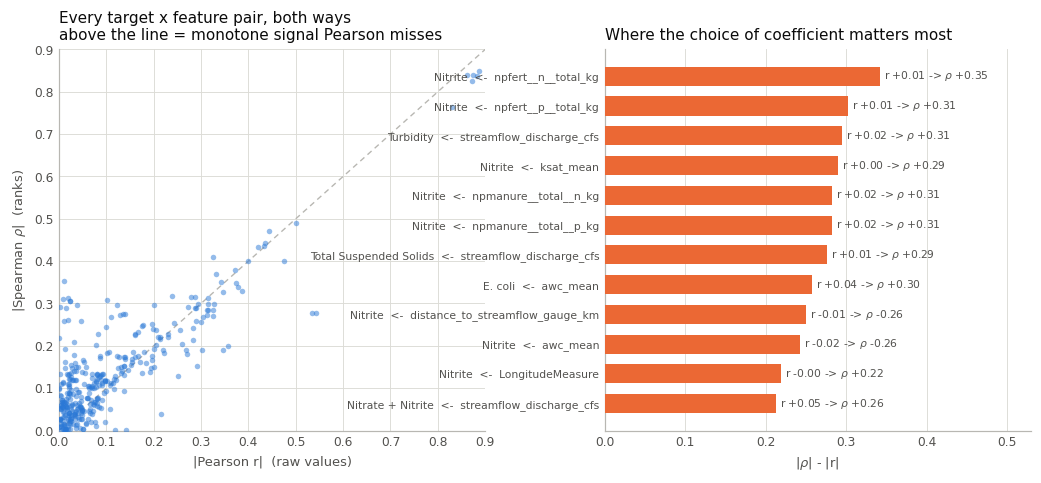

29% of the 360 pairs gain more than 0.05 of association by switching to ranks; 7% lose that much.
median |Pearson| 0.062  vs  median |Spearman| 0.111


In [6]:
pairs = []
for tlabel, tcol in TARGET_COLS.items():
    for f in FEATURE_COLS:
        v = mv[[tcol, f]].dropna()
        if len(v) < 200:
            continue
        pairs.append({
            "target": tlabel, "feature": f, "n": len(v),
            "pearson": v[tcol].corr(v[f]),
            "spearman": v[tcol].corr(v[f], method="spearman"),
        })
pr_sp = pd.DataFrame(pairs)
pr_sp["gap"] = pr_sp["spearman"].abs() - pr_sp["pearson"].abs()
pr_sp.to_csv(OUT_DIR / "mv_pearson_vs_spearman.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.5), gridspec_kw={"wspace": 0.28})

ax = axes[0]
ax.axline((0, 0), slope=1, color=AXISLINE, linewidth=0.9, linestyle=(0, (4, 3)), zorder=1)
ax.scatter(pr_sp["pearson"].abs(), pr_sp["spearman"].abs(), s=13, color=BLUE,
           alpha=0.5, linewidths=0, zorder=3)
style_axes(ax, axis="both")
ax.set_xlabel("|Pearson r|  (raw values)")
ax.set_ylabel(r"|Spearman $\rho$|  (ranks)")
ax.set_title("Every target x feature pair, both ways\n"
             "above the line = monotone signal Pearson misses", loc="left")
ax.set_xlim(0, 0.9); ax.set_ylim(0, 0.9)

ax = axes[1]
worst = pr_sp.nlargest(12, "gap").sort_values("gap")
lbl = worst["target"] + "  <-  " + worst["feature"]
ax.barh(lbl, worst["gap"], color=ORANGE, height=0.64, zorder=3)
for y, (g, p, s) in enumerate(zip(worst["gap"], worst["pearson"], worst["spearman"])):
    ax.text(g + 0.005, y, f"r {p:+.2f} -> $\\rho$ {s:+.2f}", va="center",
            fontsize=7, color=INK_SOFT)
style_axes(ax, axis="x")
ax.set_xlim(0, worst["gap"].max() * 1.55)
ax.set_xlabel(r"|$\rho$| - |r|")
ax.set_title("Where the choice of coefficient matters most", loc="left")
ax.tick_params(axis="y", labelsize=7)
plt.show()

print(f"{(pr_sp['gap'] > 0.05).mean() * 100:.0f}% of the {len(pr_sp):,} pairs gain more than "
      f"0.05 of association by switching to ranks; "
      f"{(pr_sp['gap'] < -0.05).mean() * 100:.0f}% lose that much.")
print(f"median |Pearson| {pr_sp['pearson'].abs().median():.3f}  vs  "
      f"median |Spearman| {pr_sp['spearman'].abs().median():.3f}")

## 2. Feature ↔ feature — how many independent inputs are there really?

The models are handed 30 columns. That is not the same as 30 pieces of information. Four
of them are PRISM climate variables measured at the same station on the same day; six more
are ISU weather variables measured the same way; five are land-cover percentages of the
same watershed. Within each of those blocks the columns are near-restatements of one
another, and correlation is what proves it.

This matters differently per model family:

- **Linear regression** is directly damaged. Collinear inputs make the coefficient solution
  ill-conditioned — the fit stays fine but the coefficients become large, opposite-signed
  and unstable, so nothing can be read off them.
- **Random forest** is not damaged in accuracy, but the *importances* split arbitrarily
  between correlated twins, so "which variable matters" becomes unanswerable.
- **Gradient boosting** behaves like the forest: fine on accuracy, unreliable on attribution.

### 2.1 The clustered correlation matrix

Raw alphabetical order hides structure. Ordering the 30 features by hierarchical clustering
on distance `1 − |ρ|` puts mutual predictors next to each other, so redundancy appears as
solid blocks on the diagonal.

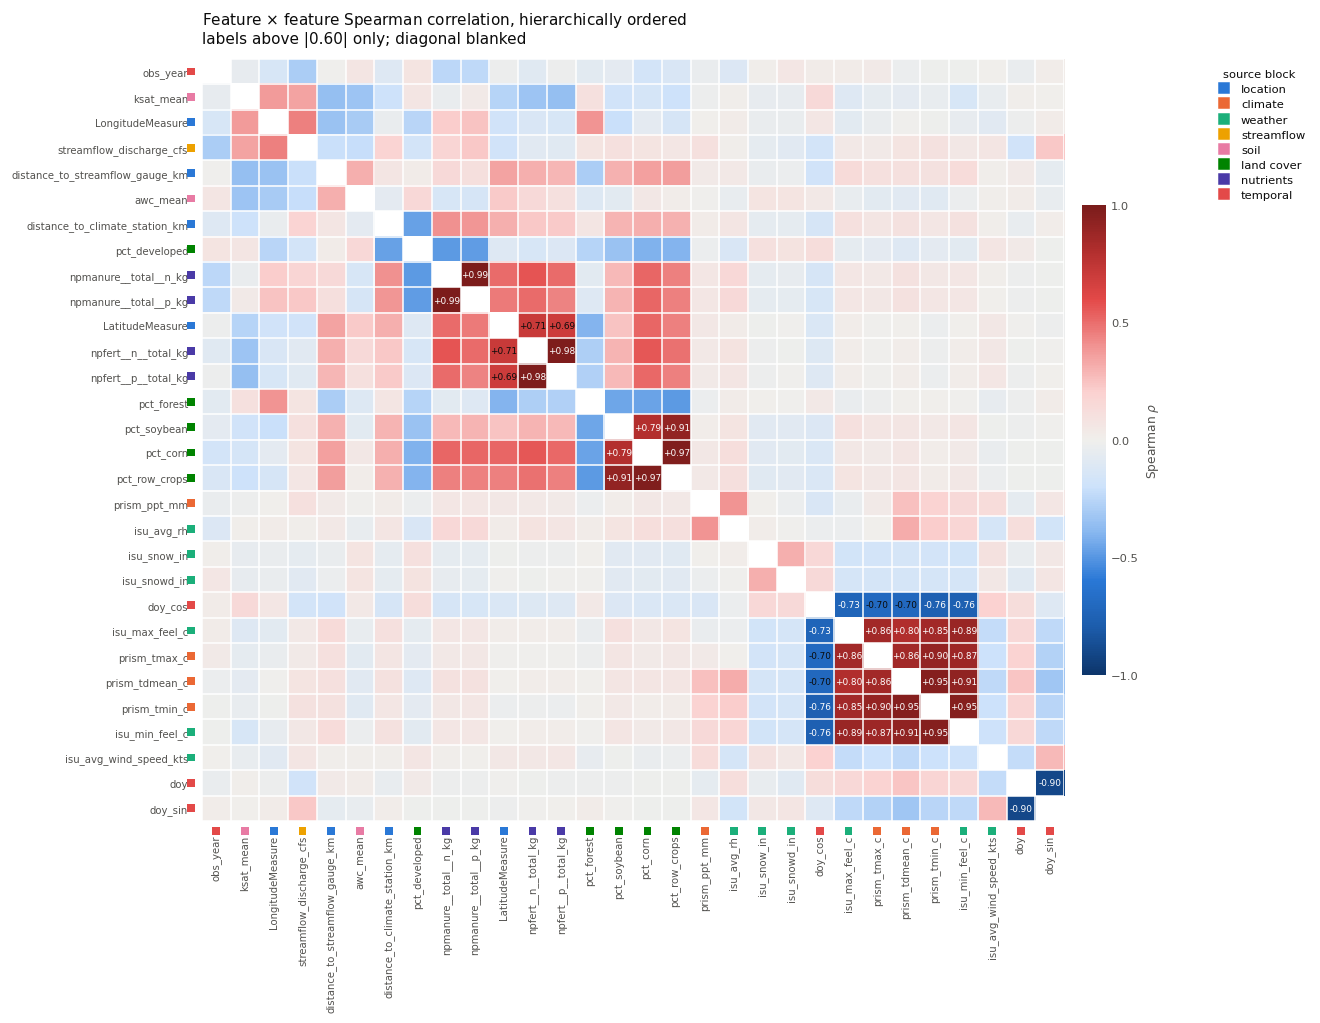

In [7]:
feat_corr = mv[FEATURE_COLS].corr(method="spearman")
feat_order, feat_Z = cluster_order(feat_corr)
feat_corr_ord = feat_corr.loc[feat_order, feat_order]
feat_corr_ord.to_csv(OUT_DIR / "mv_feature_correlation.csv")

fig, ax = plt.subplots(figsize=(10.6, 9.0))
im = heatmap(feat_corr_ord, ax, annot_at=0.60, mask_diagonal=True)
add_colorbar(fig, im, ax, r"Spearman $\rho$", ticks=[-1, -0.5, 0, 0.5, 1])

# A colour chip beside each label marks its source block, so the blocks read off the axes.
block_strip(ax, feat_corr_ord)
block_legend(ax)
ax.set_title(r"Feature $\times$ feature Spearman correlation, hierarchically ordered"
             "\nlabels above |0.60| only; diagonal blanked", loc="left", pad=10)
plt.show()

### 2.2 The redundant pairs, named

In [8]:
mask = np.triu(np.ones(feat_corr.shape, dtype=bool), k=1)
strong = (feat_corr.where(mask).stack().rename("spearman").reset_index()
          .rename(columns={"level_0": "feature_a", "level_1": "feature_b"}))
strong["abs_rho"] = strong["spearman"].abs()
strong["block_a"] = strong["feature_a"].map(FEATURE_BLOCK)
strong["block_b"] = strong["feature_b"].map(FEATURE_BLOCK)
strong["same_block"] = strong["block_a"] == strong["block_b"]
strong = strong.sort_values("abs_rho", ascending=False)
strong.to_csv(OUT_DIR / "mv_feature_pairs.csv", index=False)

for thr in (0.95, 0.90, 0.80, 0.70):
    print(f"|rho| >= {thr:.2f} : {int((strong['abs_rho'] >= thr).sum()):3d} pairs "
          f"({int(((strong['abs_rho'] >= thr) & strong['same_block']).sum())} within one source block)")

print("\nTop 20 most redundant feature pairs")
print(strong.head(20)[["feature_a", "feature_b", "spearman", "block_a", "block_b"]]
      .to_string(index=False, float_format=lambda v: f"{v:+.3f}"))

|rho| >= 0.95 :   5 pairs (4 within one source block)
|rho| >= 0.90 :   8 pairs (6 within one source block)
|rho| >= 0.80 :  15 pairs (9 within one source block)
|rho| >= 0.70 :  21 pairs (10 within one source block)

Top 20 most redundant feature pairs
            feature_a             feature_b  spearman    block_a    block_b
npmanure__total__n_kg npmanure__total__p_kg    +0.987  nutrients  nutrients
  npfert__n__total_kg   npfert__p__total_kg    +0.977  nutrients  nutrients
             pct_corn         pct_row_crops    +0.970 land cover land cover
         prism_tmin_c        isu_min_feel_c    +0.955    climate    weather
         prism_tmin_c        prism_tdmean_c    +0.954    climate    climate
       prism_tdmean_c        isu_min_feel_c    +0.915    climate    weather
          pct_soybean         pct_row_crops    +0.907 land cover land cover
                  doy               doy_sin    -0.901   temporal   temporal
         prism_tmax_c          prism_tmin_c    +0.900    clima

### 2.3 How many effectively-independent blocks?

Cutting the dendrogram at `1 − |ρ| = 0.35` (i.e. grouping anything that shares |ρ| ≥ 0.65
through a chain of mutual correlation) collapses the 30 columns into a much smaller number
of *concepts*. Each cluster is one thing the data can actually tell the model about.

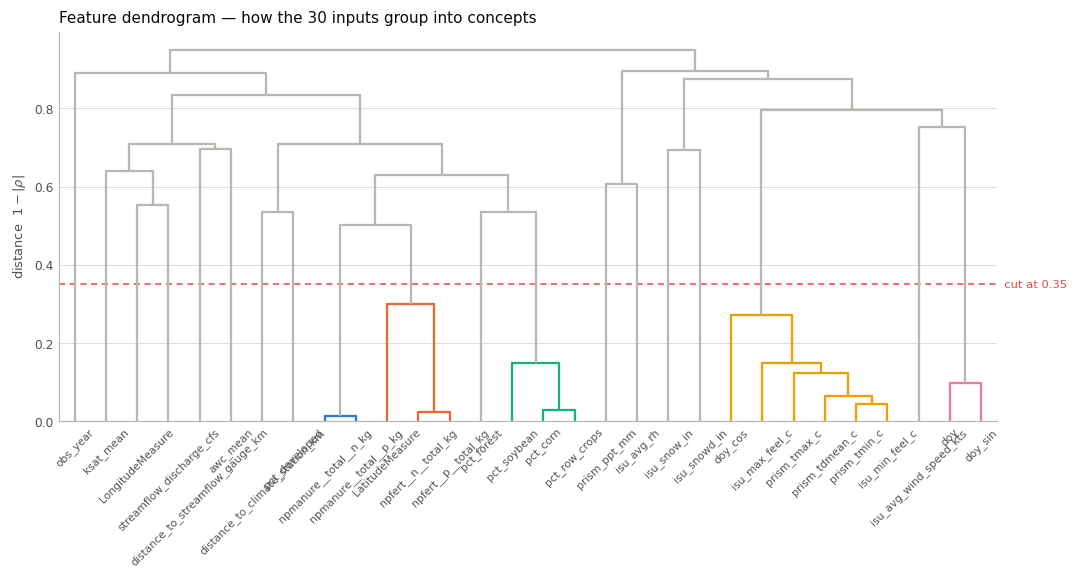

19 clusters at |rho| >= 0.65:

   1  [singleton]: LongitudeMeasure
   2  [singleton]: streamflow_discharge_cfs
   3  [singleton]: ksat_mean
   4  [singleton]: distance_to_streamflow_gauge_km
   5  [singleton]: awc_mean
   6  [singleton]: distance_to_climate_station_km
   7  [singleton]: pct_developed
   8: npmanure__total__n_kg, npmanure__total__p_kg
   9: LatitudeMeasure, npfert__n__total_kg, npfert__p__total_kg
  10: pct_corn, pct_soybean, pct_row_crops
  11  [singleton]: pct_forest
  12  [singleton]: obs_year
  13  [singleton]: prism_ppt_mm
  14  [singleton]: isu_avg_rh
  15  [singleton]: isu_snow_in
  16  [singleton]: isu_snowd_in
  17: prism_tmax_c, prism_tmin_c, prism_tdmean_c, isu_max_feel_c, isu_min_feel_c, doy_cos
  18: doy, doy_sin
  19  [singleton]: isu_avg_wind_speed_kts


In [9]:
from scipy.cluster.hierarchy import set_link_color_palette

set_link_color_palette(SERIES)          # clusters wear the fixed categorical order

CUT = 0.35
clusters = fcluster(feat_Z, t=CUT, criterion="distance")
cluster_map = pd.Series(clusters, index=feat_corr.index, name="cluster")

fig, ax = plt.subplots(figsize=(11.0, 4.6))
dn = dendrogram(feat_Z, labels=list(feat_corr.index), ax=ax, color_threshold=CUT,
                above_threshold_color=AXISLINE, leaf_font_size=7)
ax.axhline(CUT, color=RED, linewidth=1.0, linestyle=(0, (4, 3)), zorder=1)
ax.text(ax.get_xlim()[1], CUT, f"  cut at {CUT}", va="center", fontsize=7.5, color=RED)
style_axes(ax)
ax.set_ylabel(r"distance  $1 - |\rho|$")
ax.set_title("Feature dendrogram — how the 30 inputs group into concepts", loc="left")
plt.show()

summary = (cluster_map.reset_index().rename(columns={"index": "feature"})
           .groupby("cluster")["feature"].apply(list))
print(f"{len(summary)} clusters at |rho| >= {1 - CUT:.2f}:\n")
for cid, feats in summary.items():
    tag = "  [singleton]" if len(feats) == 1 else ""
    print(f"  {cid:2d}{tag}: {', '.join(feats)}")
cluster_map.to_frame().to_csv(OUT_DIR / "mv_feature_clusters.csv")

### 2.4 Variance inflation and conditioning

The dendrogram shows *pairwise* redundancy. **Variance inflation factors** catch the other
kind — a feature that no single other feature predicts, but that a *combination* of them
reconstructs. VIF for feature *i* is `1 / (1 − R²ᵢ)` where R²ᵢ is from regressing feature
*i* on all 29 others; it equals the *i*-th diagonal of the inverted correlation matrix.

Conventional reading: VIF > 5 is notable, **VIF > 10 is severe**, and VIF → ∞ means an
*exact* linear dependency — a feature that is a formula of others, contributing no
information at all. The **condition number** (√(λ_max/λ_min) of the correlation matrix)
summarises the whole design: > 30 indicates serious collinearity, and an infinite condition
number means the matrix is singular.

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Median imputation matches what the fitted pipelines do internally, so this is the
# design matrix the estimators actually see.
X_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(mv[FEATURE_COLS]),
                     columns=FEATURE_COLS, index=mv.index)
X_std = pd.DataFrame(StandardScaler().fit_transform(X_imp), columns=FEATURE_COLS)

R = X_std.corr()                       # Pearson, on the imputed matrix the model sees
Rinv = np.linalg.pinv(R.to_numpy())
vif = pd.Series(np.diag(Rinv), index=FEATURE_COLS, name="VIF").sort_values(ascending=False)
eigval, eigvec = np.linalg.eigh(R.to_numpy())
rank = int(np.linalg.matrix_rank(R.to_numpy(), tol=1e-10))
TOL = 1e-9
pos = eigval[eigval > TOL]
cond = float(np.sqrt(pos.max() / pos.min())) if len(pos) == len(eigval) else np.inf

vif.to_frame().assign(block=lambda d: d.index.map(FEATURE_BLOCK)).to_csv(OUT_DIR / "mv_vif.csv")

fig, ax = plt.subplots(figsize=(8.4, 7.4))
v = vif.sort_values()
colors = [RED if x >= 10 else (ORANGE if x >= 5 else BLUE) for x in v]
ax.barh(v.index, v.values, color=colors, height=0.66, zorder=3)
for y, x in zip(v.index, v.values):
    ax.text(x * 1.06, y, f"{x:,.1f}", va="center", fontsize=7, color=INK_SOFT)
ax.axvline(5, color=AXISLINE, linewidth=0.9, linestyle=(0, (3, 3)), zorder=2)
ax.axvline(10, color=AXISLINE, linewidth=0.9, linestyle=(0, (3, 3)), zorder=2)
ax.set_xscale("log")
style_axes(ax, axis="x")
ax.set_xlabel("variance inflation factor (log scale) — dashed guides at 5 and 10")
ax.set_title("How much of each feature is already carried by the other 29?\n"
             "red >= 10 (severe), orange >= 5 (notable)", loc="left")
plt.show()

print(f"features with VIF >= 10 : {int((vif >= 10).sum())}   VIF >= 5 : {int((vif >= 5).sum())}")
print(f"rank of the 30-feature correlation matrix : {rank} / 30")
print(f"condition number                          : "
      f"{'infinite (singular)' if not np.isfinite(cond) else f'{cond:,.0f}'}")
print(f"smallest eigenvalue                       : {eigval.min():.2e}")

features with VIF >= 10 : 8   VIF >= 5 : 9
rank of the 30-feature correlation matrix : 29 / 30
condition number                          : infinite (singular)
smallest eigenvalue                       : -6.78e-15


A rank below 30 is not a matter of degree — it means one column is a **deterministic
function** of others. The eigenvectors belonging to the near-zero eigenvalues name the
offending combinations directly: each one is a weighted sum of standardised features that
is constant across all 48,251 rows.

In [11]:
null_dirs = []
for k in np.argsort(eigval)[:3]:
    v = pd.Series(eigvec[:, k], index=FEATURE_COLS)
    v = v[v.abs() > 0.05].sort_values(key=np.abs, ascending=False)
    null_dirs.append({"eigenvalue": eigval[k],
                      "combination": "  ".join(f"{c:+.2f}*{n}" for n, c in v.items())})
    print(f"eigenvalue {eigval[k]:+.2e}")
    for n, c in v.items():
        print(f"      {c:+.3f}  {n}")
    print()
pd.DataFrame(null_dirs).to_csv(OUT_DIR / "mv_null_space.csv", index=False)

eigenvalue -6.78e-15
      +0.795  pct_row_crops
      -0.502  pct_corn
      -0.340  pct_soybean

eigenvalue +7.38e-03
      -0.527  npfert__n__total_kg
      +0.505  npfert__p__total_kg
      +0.487  npmanure__total__p_kg
      -0.472  npmanure__total__n_kg

eigenvalue +1.08e-02
      +0.535  npmanure__total__n_kg
      -0.501  npfert__n__total_kg
      -0.500  npmanure__total__p_kg
      +0.457  npfert__p__total_kg



### 2.5 PCA — the effective dimensionality

If the 30 features were independent, each principal component would carry 1/30 ≈ 3.3% of
the variance and it would take all 30 to reach 95%. The gap between that and what actually
happens *is* the redundancy, expressed as a single number.

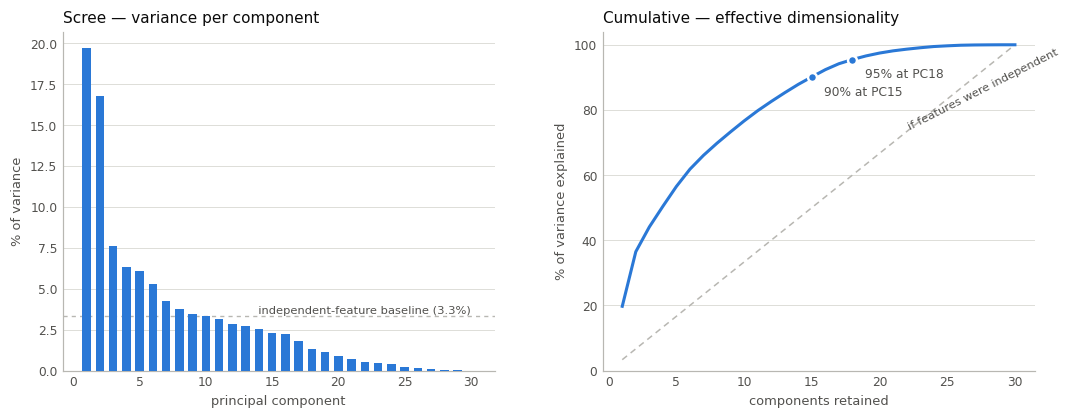

PC1 alone explains 19.7% of the 30-feature variance; PC1-PC3 explain 44.1%.
15 components reach 90% of the variance, 18 reach 95% (30 independent features would need 27 and 29).


In [12]:
from sklearn.decomposition import PCA

pca = PCA().fit(X_std.to_numpy())
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
k95 = int(np.searchsorted(cum, 0.95) + 1)
k90 = int(np.searchsorted(cum, 0.90) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0), gridspec_kw={"wspace": 0.25})

ax = axes[0]
ax.bar(np.arange(1, 31), evr * 100, color=BLUE, width=0.64, zorder=3)
ax.axhline(100 / 30, color=AXISLINE, linewidth=0.9, linestyle=(0, (3, 3)), zorder=2)
ax.text(30, 100 / 30, "  independent-feature baseline (3.3%)", va="bottom", ha="right",
        fontsize=7.5, color=INK_SOFT)
style_axes(ax)
ax.set_xlabel("principal component"); ax.set_ylabel("% of variance")
ax.set_title("Scree — variance per component", loc="left")

ax = axes[1]
ax.plot(np.arange(1, 31), cum * 100, color=BLUE, linewidth=2, zorder=3)
ax.scatter([k90, k95], [cum[k90 - 1] * 100, cum[k95 - 1] * 100], s=34, color=BLUE,
           zorder=4, edgecolor=SURFACE, linewidth=1.6)
for k, lab in ((k90, "90%"), (k95, "95%")):
    ax.annotate(f"{lab} at PC{k}", (k, cum[k - 1] * 100), textcoords="offset points",
                xytext=(8, -12), fontsize=8, color=INK_SOFT)
ax.plot(np.arange(1, 31), np.arange(1, 31) / 30 * 100, color=AXISLINE, linewidth=1,
        linestyle=(0, (4, 3)), zorder=2)
ax.text(22, 74, "if features were independent", fontsize=7.5, color=INK_SOFT, rotation=27)
style_axes(ax)
ax.set_ylim(0, 104)
ax.set_xlabel("components retained"); ax.set_ylabel("% of variance explained")
ax.set_title("Cumulative — effective dimensionality", loc="left")
plt.show()

print(f"PC1 alone explains {evr[0] * 100:.1f}% of the 30-feature variance; "
      f"PC1-PC3 explain {cum[2] * 100:.1f}%.")
print(f"{k90} components reach 90% of the variance, {k95} reach 95% "
      f"(30 independent features would need 27 and 29).")

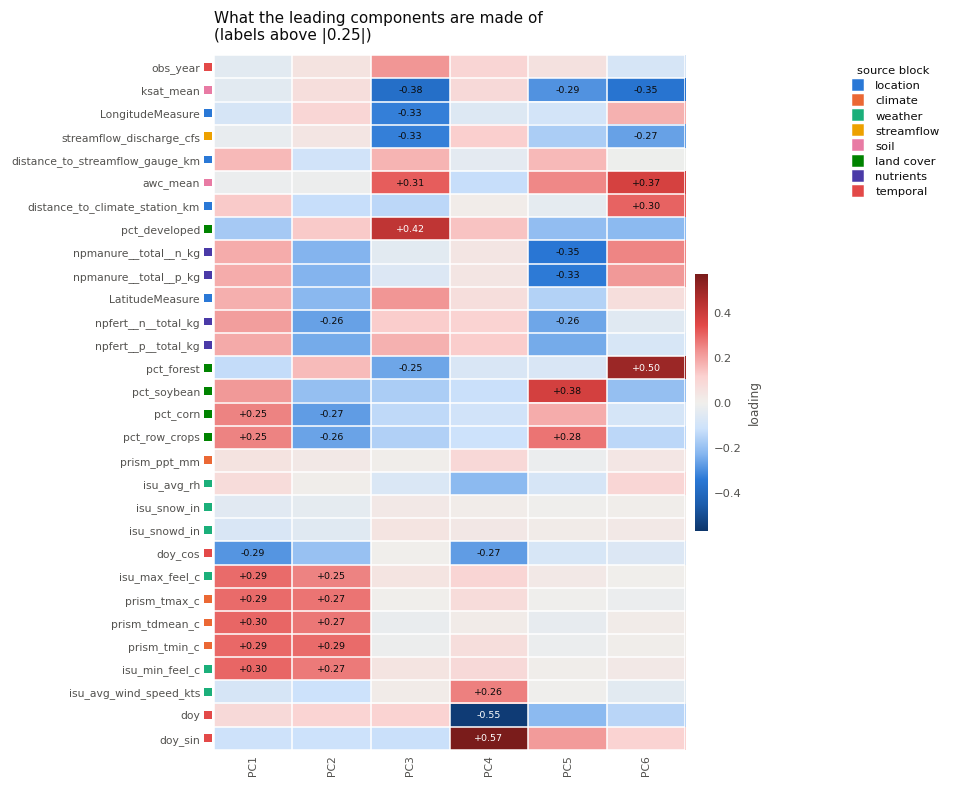

PC1 (19.7%): prism_tdmean_c +0.30, isu_min_feel_c +0.30, prism_tmin_c +0.29, prism_tmax_c +0.29, isu_max_feel_c +0.29
PC2 (16.8%): prism_tmin_c +0.29, prism_tmax_c +0.27, pct_corn -0.27, prism_tdmean_c +0.27, isu_min_feel_c +0.27
PC3 ( 7.6%): pct_developed +0.42, ksat_mean -0.38, LongitudeMeasure -0.33, streamflow_discharge_cfs -0.33, awc_mean +0.31
PC4 ( 6.3%): doy_sin +0.57, doy -0.55, doy_cos -0.27, isu_avg_wind_speed_kts +0.26, isu_avg_rh -0.22


In [13]:
# What are the leading components made of?
load = pd.DataFrame(pca.components_[:6].T, index=FEATURE_COLS,
                    columns=[f"PC{i}" for i in range(1, 7)])
load = load.loc[feat_order]
load.to_csv(OUT_DIR / "mv_pca_loadings.csv")

fig, ax = plt.subplots(figsize=(5.8, 8.2))
lim = float(np.abs(load.to_numpy()).max())
im = heatmap(load, ax, vmin=-lim, vmax=lim, annot_at=0.25, fmt="{:+.2f}", fontsize=7)
add_colorbar(fig, im, ax, "loading")
block_strip(ax, load, cols=False)
block_legend(ax, bbox_to_anchor=(1.32, 1.0))
ax.set_title("What the leading components are made of\n"
             "(labels above |0.25|)", loc="left", pad=10)
plt.show()

for i in range(4):
    top = load[f"PC{i+1}"].abs().nlargest(5).index
    parts = ", ".join(f"{c} {load.loc[c, f'PC{i+1}']:+.2f}" for c in top)
    print(f"PC{i+1} ({evr[i]*100:4.1f}%): {parts}")

### 2.6 The geometry of the feature space

Correlation describes pairs. A last, genuinely multivariate view: where do the 48,251
observations *sit* in the 30-dimensional space? Mahalanobis distance measures how far each
row is from the centre **in units of the data's own covariance**, so it counts a combination
that is unusual *given* the correlations — a warm day with high snow depth — rather than a
value that is merely large. Under multivariate normality D² follows χ²₍₃₀₎, so the deviation
from that reference curve is the non-normality of the joint distribution.

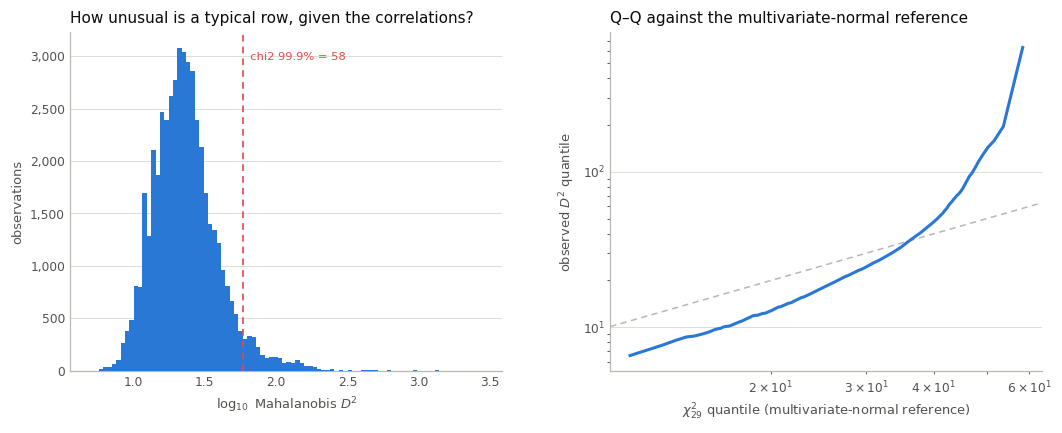

rows beyond the chi2 99.9% cut : 2,586 (5.36%  — 0.1% expected under normality)
max D^2 2,802  vs  chi2 99.9% cut 58.3


In [14]:
# D^2 in the whitened PCA basis == Mahalanobis distance, without inverting a near-singular
# covariance matrix. Components with negligible variance are dropped.
keep = pca.explained_variance_ > 1e-8
scores = pca.transform(X_std.to_numpy())[:, keep]
d2 = (scores ** 2 / pca.explained_variance_[keep]).sum(axis=1)
dfree = int(keep.sum())

from scipy import stats
q = np.linspace(0.001, 0.999, 400)
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0), gridspec_kw={"wspace": 0.25})

ax = axes[0]
ax.hist(np.log10(np.clip(d2, 1e-6, None)), bins=90, color=BLUE, zorder=3)
crit = stats.chi2.ppf(0.999, dfree)
ax.axvline(np.log10(crit), color=RED, linewidth=1.1, linestyle=(0, (4, 3)), zorder=4)
ax.text(np.log10(crit), ax.get_ylim()[1] * 0.94, f"  chi2 99.9% = {crit:,.0f}",
        fontsize=7.5, color=RED, va="top")
style_axes(ax); thousands(ax)
ax.set_xlabel(r"$\log_{10}$ Mahalanobis $D^2$"); ax.set_ylabel("observations")
ax.set_title("How unusual is a typical row, given the correlations?", loc="left")

ax = axes[1]
ax.plot(stats.chi2.ppf(q, dfree), np.quantile(d2, q), color=BLUE, linewidth=2, zorder=3)
hi = max(stats.chi2.ppf(0.999, dfree), np.quantile(d2, 0.999))
ax.axline((0, 0), slope=1, color=AXISLINE, linewidth=1, linestyle=(0, (4, 3)), zorder=2)
ax.set_xscale("log"); ax.set_yscale("log")
style_axes(ax, axis="both")
ax.set_xlabel(r"$\chi^2_{%d}$ quantile (multivariate-normal reference)" % dfree)
ax.set_ylabel(r"observed $D^2$ quantile")
ax.set_title("Q–Q against the multivariate-normal reference", loc="left")
plt.show()

print(f"rows beyond the chi2 99.9% cut : {int((d2 > crit).sum()):,} "
      f"({100 * (d2 > crit).mean():.2f}%  — 0.1% expected under normality)")
print(f"max D^2 {d2.max():,.0f}  vs  chi2 99.9% cut {crit:,.1f}")

## 3. Target ↔ target — are these 12 problems or 4?

The dashboard trains 12 independent models. If the targets are strongly inter-correlated,
that is 12 models re-learning a handful of underlying gradients, and a target with little
data could be predicted from a target with a lot of it.

### 3.1 First: how often are two targets even measured together?

A correlation between two analytes is computed only on rows where both were sampled. Before
reading any of those numbers, the overlap has to be checked — a ρ of 0.9 on 41 shared rows
is not the same object as a ρ of 0.5 on 12,000.

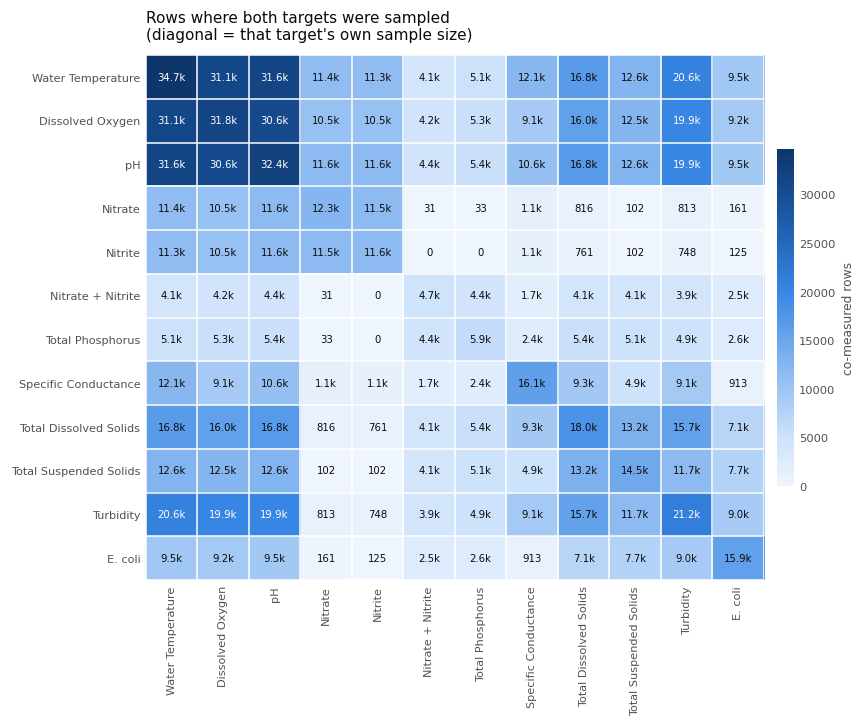

target pairs: 144   median co-measured rows 6,228
pairs with < 1,000 shared rows: 13   < 200 shared rows: 8

Thinnest overlaps:
                                shared_rows
Nitrite Nitrate + Nitrite                 0
        Total Phosphorus                  0
Nitrate Nitrate + Nitrite                31
        Total Phosphorus                 33
        Total Suspended Solids          102
Nitrite Total Suspended Solids          102


In [15]:
T = mv[TARGET_VALUE_COLS].rename(columns=COL_TO_LABEL)
present = T.notna()
overlap = present.T.astype(int) @ present.astype(int)
overlap = pd.DataFrame(overlap, index=T.columns, columns=T.columns)
overlap.to_csv(OUT_DIR / "mv_target_overlap.csv")

fig, ax = plt.subplots(figsize=(7.6, 6.2))
im = heatmap(overlap, ax, cmap=SEQUENTIAL, vmin=0, vmax=float(overlap.to_numpy().max()),
             annot_at=None, fontsize=7.4)
for i in range(len(T.columns)):
    for j in range(len(T.columns)):
        n = overlap.iat[i, j]
        ax.text(j, i, f"{n/1000:,.1f}k" if n >= 1000 else f"{n:,}", ha="center", va="center",
                fontsize=6.6,
                color="#ffffff" if n > overlap.to_numpy().max() * 0.55 else INK)
add_colorbar(fig, im, ax, "co-measured rows")
ax.set_title("Rows where both targets were sampled\n"
             "(diagonal = that target's own sample size)", loc="left", pad=10)
plt.show()

off = overlap.where(np.triu(np.ones(overlap.shape, dtype=bool), k=1)).stack()
print(f"target pairs: {len(off)}   median co-measured rows {off.median():,.0f}")
print(f"pairs with < 1,000 shared rows: {int((off < 1000).sum())}   "
      f"< 200 shared rows: {int((off < 200).sum())}")
print("\nThinnest overlaps:")
print(off.nsmallest(6).rename("shared_rows").to_frame().to_string())

### 3.2 The target correlation matrix

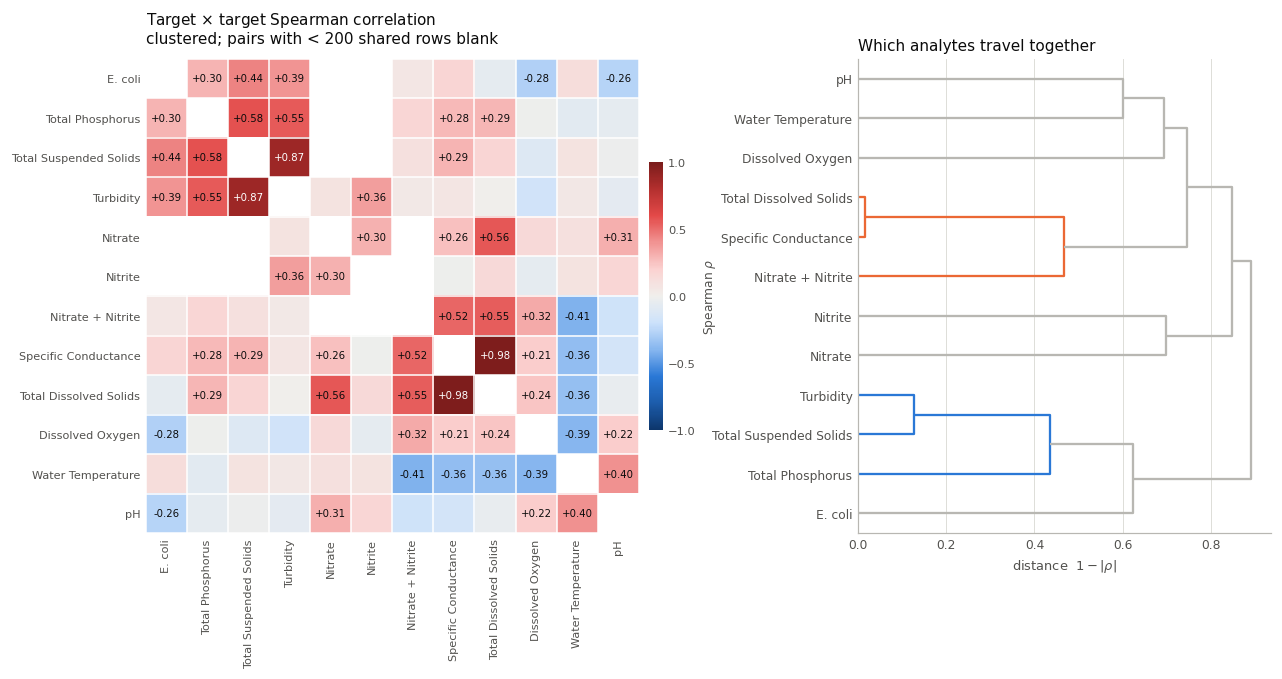

Strongest target-target relationships
              target_a               target_b  spearman  shared_rows
  Specific Conductance Total Dissolved Solids    +0.984         9285
Total Suspended Solids              Turbidity    +0.873        11687
      Total Phosphorus Total Suspended Solids    +0.577         5069
               Nitrate Total Dissolved Solids    +0.556          816
      Total Phosphorus              Turbidity    +0.552         4939
     Nitrate + Nitrite Total Dissolved Solids    +0.546         4121
     Nitrate + Nitrite   Specific Conductance    +0.518         1697
Total Suspended Solids                E. coli    +0.442         7688
     Water Temperature      Nitrate + Nitrite    -0.409         4123
     Water Temperature                     pH    +0.399        31590
     Water Temperature       Dissolved Oxygen    -0.394        31101
             Turbidity                E. coli    +0.391         9024


In [16]:
targ_corr = T.corr(method="spearman", min_periods=200)
targ_order, targ_Z = cluster_order(targ_corr)
targ_corr_ord = targ_corr.loc[targ_order, targ_order]
targ_corr_ord.to_csv(OUT_DIR / "mv_target_correlation.csv")

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6),
                         gridspec_kw={"width_ratios": [1.25, 1], "wspace": 0.42})

ax = axes[0]
im = heatmap(targ_corr_ord, ax, annot_at=0.20, fmt="{:+.2f}", fontsize=7.4,
             mask_diagonal=True)
add_colorbar(fig, im, ax, r"Spearman $\rho$", ticks=[-1, -0.5, 0, 0.5, 1])
ax.set_title(r"Target $\times$ target Spearman correlation" "\n"
             "clustered; pairs with < 200 shared rows blank", loc="left", pad=10)

ax = axes[1]
dendrogram(targ_Z, labels=list(targ_corr.index), ax=ax, orientation="right",
           color_threshold=0.6, above_threshold_color=AXISLINE, leaf_font_size=8)
style_axes(ax, axis="x")
ax.set_xlabel(r"distance  $1 - |\rho|$")
ax.set_title("Which analytes travel together", loc="left")
plt.show()

mask_t = np.triu(np.ones(targ_corr.shape, dtype=bool), k=1)
tp = (targ_corr.where(mask_t).stack().rename("spearman").reset_index()
      .rename(columns={"level_0": "target_a", "level_1": "target_b"}))
tp["shared_rows"] = [overlap.loc[a, b] for a, b in zip(tp["target_a"], tp["target_b"])]
tp["abs_rho"] = tp["spearman"].abs()
tp = tp.sort_values("abs_rho", ascending=False)
tp.to_csv(OUT_DIR / "mv_target_pairs.csv", index=False)
print("Strongest target-target relationships")
print(tp.head(12)[["target_a", "target_b", "spearman", "shared_rows"]]
      .to_string(index=False, float_format=lambda v: f"{v:+.3f}"))

## 4. Target ↔ feature — the signal matrix

This is the block the modeling stands on: for each of the 12 targets, how much does each of
the 30 inputs know about it? Read it two ways — *rows* say which features drive a target,
*columns* say which features are doing work anywhere at all.

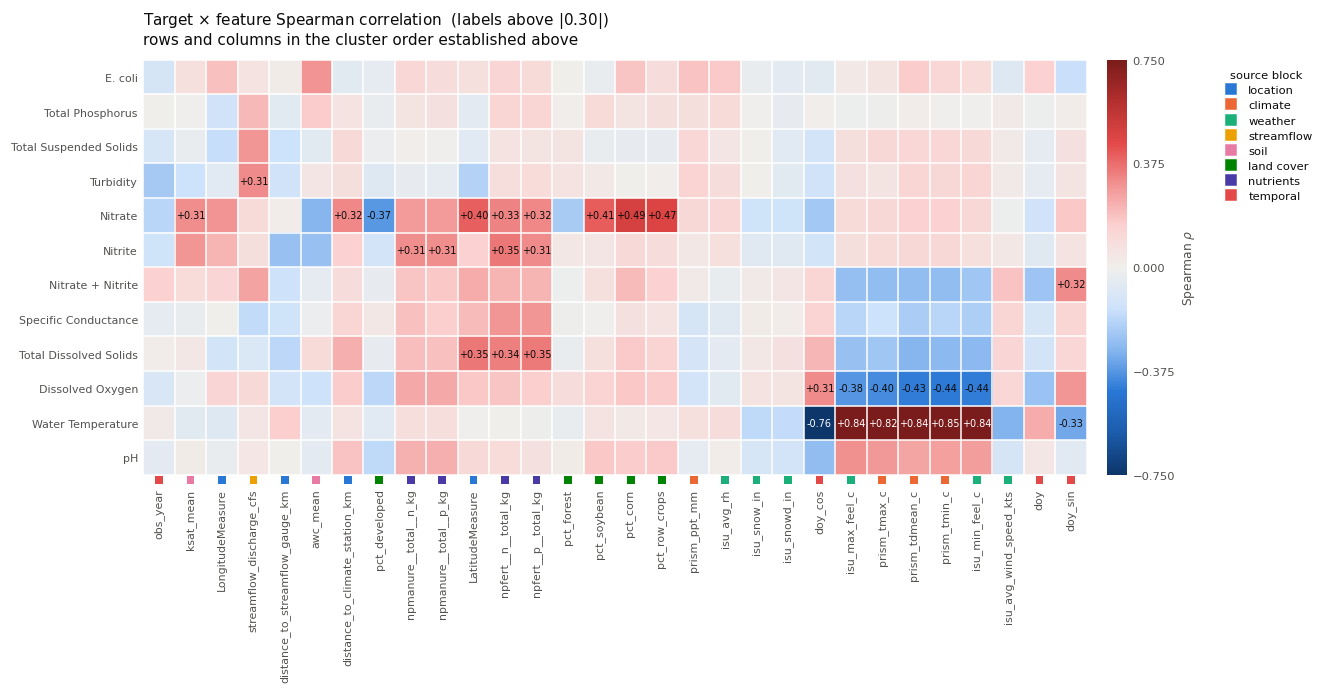

Strongest single feature per target:
  Water Temperature        prism_tmin_c                     rho = +0.849
  Nitrate                  pct_corn                         rho = +0.489
  Dissolved Oxygen         prism_tmin_c                     rho = -0.442
  Nitrite                  npfert__n__total_kg              rho = +0.353
  Total Dissolved Solids   LatitudeMeasure                  rho = +0.352
  Nitrate + Nitrite        doy_sin                          rho = +0.316
  Turbidity                streamflow_discharge_cfs         rho = +0.314
  pH                       isu_max_feel_c                   rho = +0.299
  E. coli                  awc_mean                         rho = +0.296
  Specific Conductance     npfert__n__total_kg              rho = +0.291
  Total Suspended Solids   streamflow_discharge_cfs         rho = +0.290
  Total Phosphorus         streamflow_discharge_cfs         rho = +0.209


In [17]:
both = mv[TARGET_VALUE_COLS + FEATURE_COLS].corr(method="spearman", min_periods=200)
tf = both.loc[TARGET_VALUE_COLS, FEATURE_COLS].rename(index=COL_TO_LABEL)
tf = tf.loc[targ_order, feat_order]
tf.to_csv(OUT_DIR / "mv_target_feature_correlation.csv")

fig, ax = plt.subplots(figsize=(11.6, 4.9))
lim = 0.75
im = heatmap(tf, ax, vmin=-lim, vmax=lim, annot_at=0.30, fmt="{:+.2f}", fontsize=7.2)
add_colorbar(fig, im, ax, r"Spearman $\rho$", ticks=[-0.75, -0.375, 0, 0.375, 0.75])
block_strip(ax, tf, rows=False)
block_legend(ax, bbox_to_anchor=(1.13, 1.0))
ax.set_title(r"Target $\times$ feature Spearman correlation  (labels above |0.30|)"
             "\nrows and columns in the cluster order established above",
             loc="left", pad=10)
plt.show()

row_max = tf.abs().max(axis=1).sort_values(ascending=False)
col_max = tf.abs().max(axis=0).sort_values(ascending=False)
print("Strongest single feature per target:")
for t in row_max.index:
    f = tf.loc[t].abs().idxmax()
    print(f"  {t:<24s} {f:<32s} rho = {tf.loc[t, f]:+.3f}")

### 4.1 The strongest drivers, per target

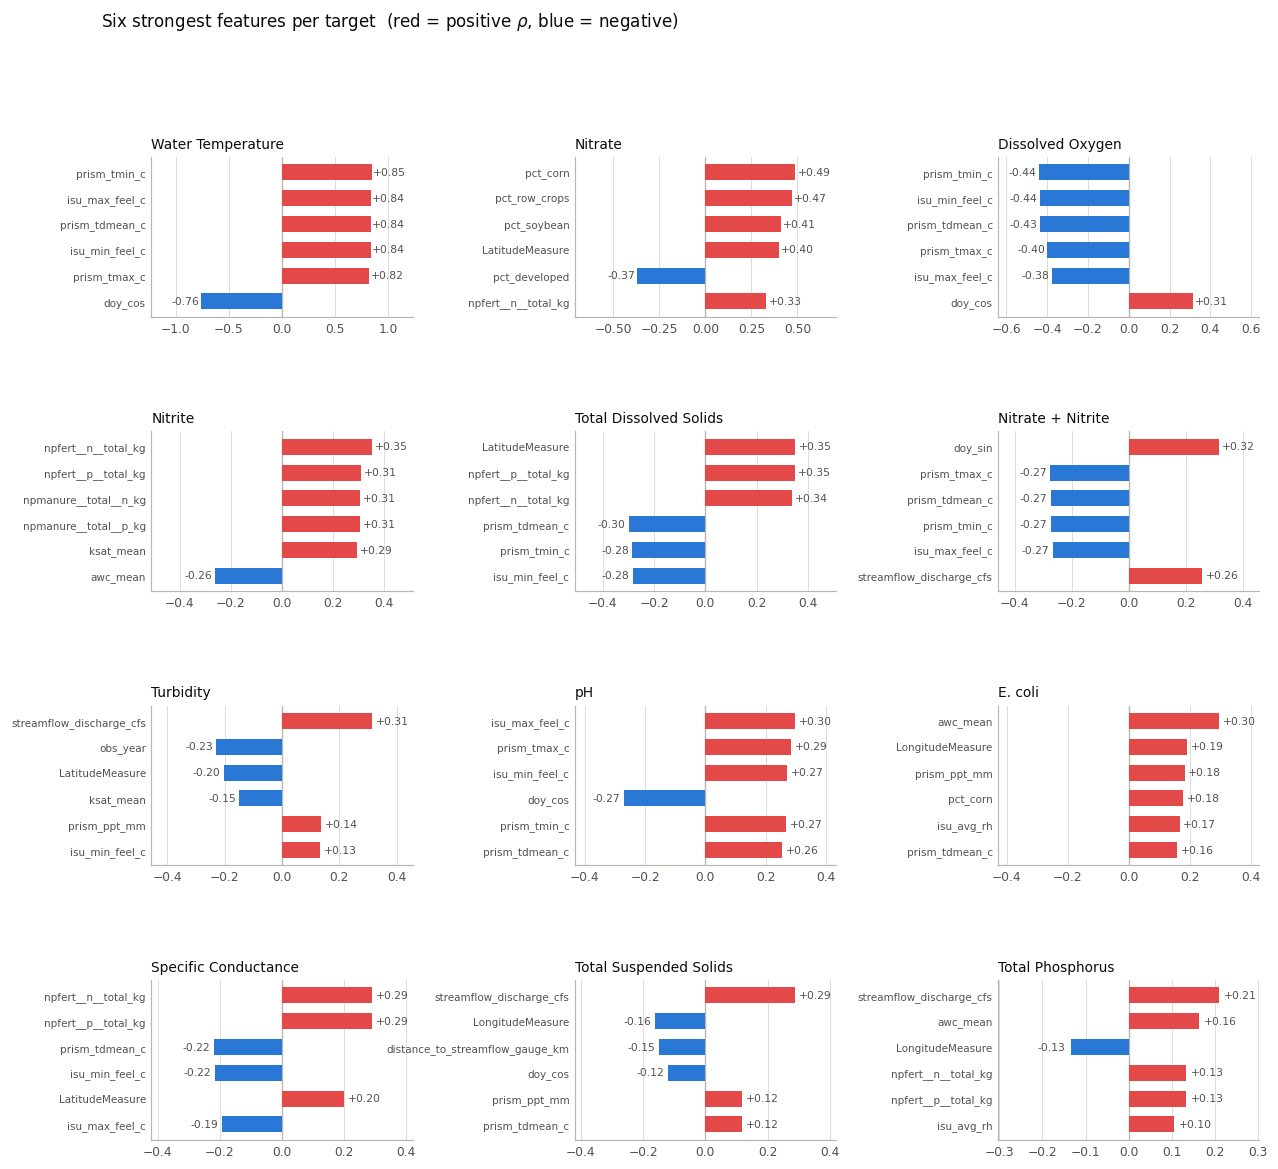

In [18]:
TOPK = 6
fig, axes = plt.subplots(4, 3, figsize=(13.0, 11.6),
                         gridspec_kw={"hspace": 0.72, "wspace": 0.62})
for ax, t in zip(axes.ravel(), row_max.index):
    s = tf.loc[t].dropna()
    top = s.reindex(s.abs().sort_values(ascending=False).index[:TOPK])[::-1]
    ax.barh(top.index, top.values, height=0.62, zorder=3,
            color=[RED if v > 0 else BLUE for v in top.values])
    ax.axvline(0, color=AXISLINE, linewidth=0.9, zorder=2)
    for y, v in enumerate(top.values):
        ax.text(v + (0.012 if v >= 0 else -0.012), y, f"{v:+.2f}", va="center",
                ha="left" if v >= 0 else "right", fontsize=7, color=INK_SOFT)
    style_axes(ax, axis="x")
    m = float(np.abs(top.values).max())
    ax.set_xlim(-m * 1.45, m * 1.45)
    ax.set_title(t, loc="left", fontsize=9)
    ax.tick_params(axis="y", labelsize=6.8)
fig.suptitle(r"Six strongest features per target  (red = positive $\rho$, blue = negative)",
             x=0.09, ha="left", fontsize=11, y=0.995)
plt.show()

### 4.2 Correlation ceiling vs. reported model performance

A single feature's |ρ| is a floor, not a ceiling, on what a model can do — a forest combines
30 of them and exploits interactions. But the comparison is still informative: where the
reported R² is far above anything the correlation structure suggests, the extra performance
is coming from somewhere other than these relationships, and §6 identifies where.

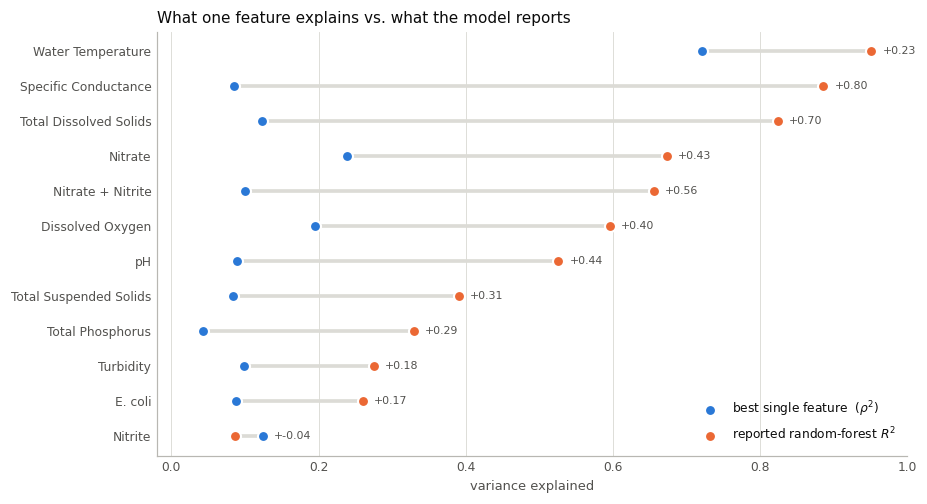

                        max_abs_rho  rho_squared  rf_r2    gap
Specific Conductance          0.291        0.084  0.886  0.802
Total Dissolved Solids        0.352        0.124  0.824  0.701
Nitrate + Nitrite             0.316          0.1  0.656  0.556
pH                            0.299         0.09  0.526  0.436
Nitrate                       0.489        0.239  0.674  0.435
Dissolved Oxygen              0.442        0.195  0.596  0.401
Total Suspended Solids         0.29        0.084  0.391  0.307
Total Phosphorus              0.209        0.044   0.33  0.286
Water Temperature             0.849        0.721  0.952  0.231
Turbidity                     0.314        0.099  0.275  0.176
E. coli                       0.296        0.088   0.26  0.173
Nitrite                       0.353        0.124  0.086 -0.038


In [19]:
metrics = pd.read_csv(METRICS_PATH)
rf = metrics[metrics["model"] == "Random Forest"].set_index("target")["r2"]

cmp = pd.DataFrame({
    "max_abs_rho": row_max,
    "rho_squared": row_max ** 2,
    "rf_r2": rf.reindex(row_max.index),
}).dropna()
cmp["gap"] = cmp["rf_r2"] - cmp["rho_squared"]
cmp.to_csv(OUT_DIR / "mv_correlation_vs_model_r2.csv")

fig, ax = plt.subplots(figsize=(8.8, 5.0))
y = np.arange(len(cmp))
o = cmp.sort_values("rf_r2")
ax.hlines(y, o["rho_squared"], o["rf_r2"], color=GRIDLINE, linewidth=2.4, zorder=2)
ax.scatter(o["rho_squared"], y, s=52, color=BLUE, zorder=3, edgecolor=SURFACE, linewidth=1.4,
           label=r"best single feature  ($\rho^2$)")
ax.scatter(o["rf_r2"], y, s=52, color=ORANGE, zorder=3, edgecolor=SURFACE, linewidth=1.4,
           label=r"reported random-forest $R^2$")
for i, (a, b) in enumerate(zip(o["rho_squared"], o["rf_r2"])):
    ax.text(max(a, b) + 0.015, i, f"+{b - a:.2f}", va="center", fontsize=7.2, color=INK_SOFT)
ax.set_yticks(y); ax.set_yticklabels(o.index, fontsize=8)
style_axes(ax, axis="x")
ax.set_xlim(-0.02, 1.0)
ax.set_xlabel("variance explained")
ax.set_title("What one feature explains vs. what the model reports", loc="left")
ax.legend(loc="lower right", fontsize=8)
plt.show()

print(cmp.sort_values("gap", ascending=False).round(3).to_string())

## 5. Linear or not? — mutual information

Spearman finds *monotone* association. It is blind to a relationship that goes up and then
down — which is exactly the shape of most seasonal and threshold effects in surface water.
**Mutual information** has no such blind spot: it measures any statistical dependence,
including non-monotone ones, but it has no sign and no natural scale.

To put MI on the same axis as ρ, each MI value is converted to the correlation a bivariate
normal would need to carry the same information:

$$|r_{\text{equiv}}| = \sqrt{1 - e^{-2\,\text{MI}}}$$

A pair where **r_equiv is high and |ρ| is near zero is a real relationship that no monotone
summary — and no untransformed linear model — can see.**

One correction is essential. The k-nearest-neighbour MI estimator is **biased upward**: on
finite samples it returns a positive number even for two independent variables, and the
bias grows with sample size and with how clumped the feature is. Taking the raw estimate at
face value would invent non-linear structure everywhere. So every MI here is measured
against its own **permutation null** — the same estimator run on a shuffled target, which
destroys any real relationship while preserving both marginals. What is reported is the
excess over that null.

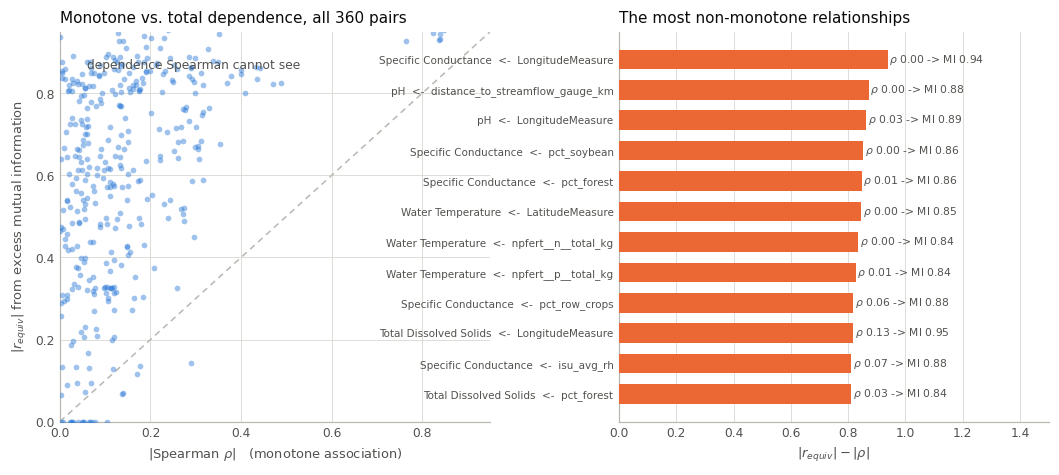

mean raw MI 0.349 nats, of which the permutation null accounts for 0.003 (1%) — that share is estimator bias, not signal.
pairs where MI implies >= 0.15 more association than Spearman: 317 of 360
pairs with essentially no dependence at all (excess MI <= 0.01): 28


In [20]:
from sklearn.feature_selection import mutual_info_regression

MI_SUBSAMPLE = 6000
N_PERM = 3
rng = np.random.default_rng(0)
mi_rows = []
for tlabel, tcol in TARGET_COLS.items():
    sub = mv[[tcol] + FEATURE_COLS].dropna(subset=[tcol])
    if len(sub) > MI_SUBSAMPLE:
        sub = sub.iloc[rng.choice(len(sub), MI_SUBSAMPLE, replace=False)]
    Xs = SimpleImputer(strategy="median").fit_transform(sub[FEATURE_COLS])
    y = sub[tcol].to_numpy()
    mi = mutual_info_regression(Xs, y, random_state=0)
    null = np.mean([mutual_info_regression(Xs, rng.permutation(y), random_state=0)
                    for _ in range(N_PERM)], axis=0)
    excess = np.clip(mi - null, 0, None)
    for f, m, nl, e in zip(FEATURE_COLS, mi, null, excess):
        mi_rows.append({"target": tlabel, "feature": f, "mi_raw": float(m),
                        "mi_null": float(nl), "mi": float(e),
                        "r_equiv": float(np.sqrt(1 - np.exp(-2 * e))),
                        "n_used": len(sub)})
mi_df = pd.DataFrame(mi_rows)
mi_df["abs_rho"] = [abs(tf.loc[t, f]) if not pd.isna(tf.loc[t, f]) else np.nan
                    for t, f in zip(mi_df["target"], mi_df["feature"])]
mi_df["nonlinear_excess"] = mi_df["r_equiv"] - mi_df["abs_rho"]
mi_df.to_csv(OUT_DIR / "mv_mutual_information.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6), gridspec_kw={"wspace": 0.3})

ax = axes[0]
ax.axline((0, 0), slope=1, color=AXISLINE, linewidth=1, linestyle=(0, (4, 3)), zorder=2)
ax.scatter(mi_df["abs_rho"], mi_df["r_equiv"], s=14, color=BLUE, alpha=0.45,
           linewidths=0, zorder=3)
ax.text(0.06, 0.86, "dependence Spearman cannot see", fontsize=8, color=INK_SOFT)
style_axes(ax, axis="both")
ax.set_xlabel(r"|Spearman $\rho$|   (monotone association)")
ax.set_ylabel(r"$|r_{equiv}|$ from excess mutual information")
ax.set_title("Monotone vs. total dependence, all 360 pairs", loc="left")
ax.set_xlim(0, 0.95); ax.set_ylim(0, 0.95)

ax = axes[1]
top = mi_df.nlargest(12, "nonlinear_excess").sort_values("nonlinear_excess")
lbl = top["target"] + "  <-  " + top["feature"]
ax.barh(lbl, top["nonlinear_excess"], color=ORANGE, height=0.64, zorder=3)
for y, (e, r, m) in enumerate(zip(top["nonlinear_excess"], top["abs_rho"], top["r_equiv"])):
    ax.text(e + 0.006, y, f"$\\rho$ {r:.2f} -> MI {m:.2f}", va="center", fontsize=7,
            color=INK_SOFT)
style_axes(ax, axis="x")
ax.set_xlim(0, top["nonlinear_excess"].max() * 1.6)
ax.set_xlabel(r"$|r_{equiv}| - |\rho|$")
ax.set_title("The most non-monotone relationships", loc="left")
ax.tick_params(axis="y", labelsize=6.8)
plt.show()

print(f"mean raw MI {mi_df['mi_raw'].mean():.3f} nats, of which the permutation null "
      f"accounts for {mi_df['mi_null'].mean():.3f} "
      f"({100 * mi_df['mi_null'].mean() / mi_df['mi_raw'].mean():.0f}%) — "
      f"that share is estimator bias, not signal.")
print(f"pairs where MI implies >= 0.15 more association than Spearman: "
      f"{int((mi_df['nonlinear_excess'] >= 0.15).sum())} of {len(mi_df)}")
print(f"pairs with essentially no dependence at all (excess MI <= 0.01): "
      f"{int((mi_df['mi'] <= 0.01).sum())}")

### 5.1 What the extra dependence actually is

The result above should be read carefully rather than celebrated. The permutation null came
back near zero, so the excess is not estimator bias — the dependence is really in the data.
But look at *which* pairs carry it: `Specific Conductance ← LongitudeMeasure` has
|ρ| = 0.001 and an MI-implied r_equiv of **0.94**. Longitude is not a mechanism for
conductance. It is an **address**.

Longitude takes ~1,326 distinct values across 1,345 stations, so knowing it is equivalent to
knowing which station the sample came from — and knowing the station tells you that site's
typical conductance. Mutual information is scoring a *lookup table*, and it does so most
strongly for exactly the features that never change at a station.

The test is direct: plot each feature's mean MI-implied dependence against the share of its
variance that lies **between** stations rather than within them. If the extra dependence
were mechanism, there would be no relationship between those two quantities.

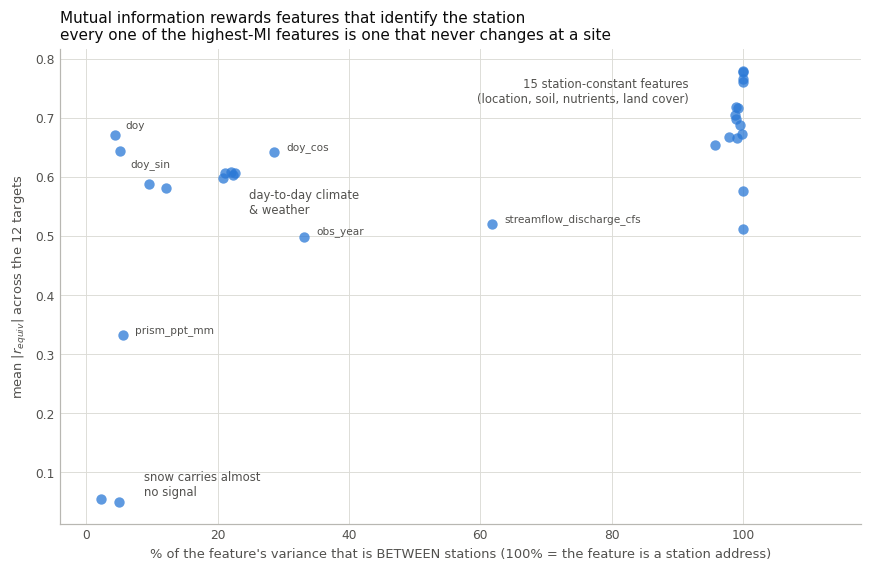

Spearman correlation between 'how well the feature identifies the station' and 'how much MI it carries': +0.582

Top 8 by MI-implied dependence:
                                 mean_r_equiv  mean_abs_rho  between_share  unique_values_per_station
feature                                                                                              
LatitudeMeasure                         0.780         0.167          1.000                      0.984
LongitudeMeasure                        0.778         0.130          1.000                      0.986
distance_to_streamflow_gauge_km         0.766         0.116          1.000                      0.989
distance_to_climate_station_km          0.762         0.136          1.000                      0.990
npfert__n__total_kg                     0.718         0.184          0.989                      0.147
npfert__p__total_kg                     0.717         0.175          0.992                      0.147
npmanure__total__p_kg                  

In [21]:
rows = []
for c in FEATURE_COLS:
    v = mv[[ID_COL, c]].dropna()
    total = v[c].var()
    between = v.groupby(ID_COL)[c].transform("mean").var()
    rows.append({
        "feature": c,
        "between_share": between / total if total else np.nan,
        "unique_values_per_station": v[c].nunique() / v[ID_COL].nunique(),
    })
ident = pd.DataFrame(rows).set_index("feature")
ident["mean_r_equiv"] = mi_df.groupby("feature")["r_equiv"].mean()
ident["mean_abs_rho"] = mi_df.groupby("feature")["abs_rho"].mean()
ident["block"] = ident.index.map(FEATURE_BLOCK)
ident.to_csv(OUT_DIR / "mv_station_identifiability.csv")

fig, ax = plt.subplots(figsize=(9.4, 5.6))
ax.scatter(ident["between_share"] * 100, ident["mean_r_equiv"], s=46, color=BLUE,
           alpha=0.75, linewidths=0, zorder=3)
# The right-hand cluster is 14 overlapping points; call it out as a group rather than
# stacking 14 labels on top of each other. Only the sparse left side gets per-point labels.
# Label a curated set individually; the two dense clusters get one callout each, so no
# label is ever stacked on another.
SOLO = {"doy": (7, 4), "doy_sin": (7, -10), "prism_ppt_mm": (8, 1), "doy_cos": (8, 2),
        "obs_year": (8, 2), "streamflow_discharge_cfs": (8, 2)}
for c, (dx, dy) in SOLO.items():
    r = ident.loc[c]
    ax.annotate(c, (r["between_share"] * 100, r["mean_r_equiv"]),
                textcoords="offset points", xytext=(dx, dy), fontsize=6.9, color=INK_SOFT)

n_addr = int((ident["between_share"] > 0.95).sum())
ax.annotate(f"{n_addr} station-constant features\n(location, soil, nutrients, land cover)",
            (95, 0.71), textcoords="offset points", xytext=(-14, 6), ha="right",
            fontsize=7.6, color=INK_SOFT)
ax.annotate("day-to-day climate\n& weather", (22, 0.60), textcoords="offset points",
            xytext=(12, -24), fontsize=7.6, color=INK_SOFT)
ax.annotate("snow carries almost\nno signal", (5, 0.05), textcoords="offset points",
            xytext=(16, 4), fontsize=7.6, color=INK_SOFT)
style_axes(ax, axis="both")
ax.set_xlim(-4, 118)
ax.set_xlabel("% of the feature's variance that is BETWEEN stations "
              "(100% = the feature is a station address)")
ax.set_ylabel(r"mean $|r_{equiv}|$ across the 12 targets")
ax.set_title("Mutual information rewards features that identify the station\n"
             "every one of the highest-MI features is one that never changes at a site",
             loc="left")
plt.show()

rho_id = ident["between_share"].corr(ident["mean_r_equiv"], method="spearman")
print(f"Spearman correlation between 'how well the feature identifies the station' and "
      f"'how much MI it carries': {rho_id:+.3f}")
print("\nTop 8 by MI-implied dependence:")
print(ident.nlargest(8, "mean_r_equiv")[["mean_r_equiv", "mean_abs_rho", "between_share",
                                         "unique_values_per_station"]]
      .to_string(float_format=lambda v: f"{v:.3f}"))

### 5.2 What those relationships actually look like

A scatter of 30,000 points is a solid blob. Binned medians with an interquartile band show
the conditional distribution instead: the line is the median target value in each decile-ish
bin of the feature, the band is Q1–Q3 within the bin. The shape — monotone, humped,
threshold — is the thing to read.

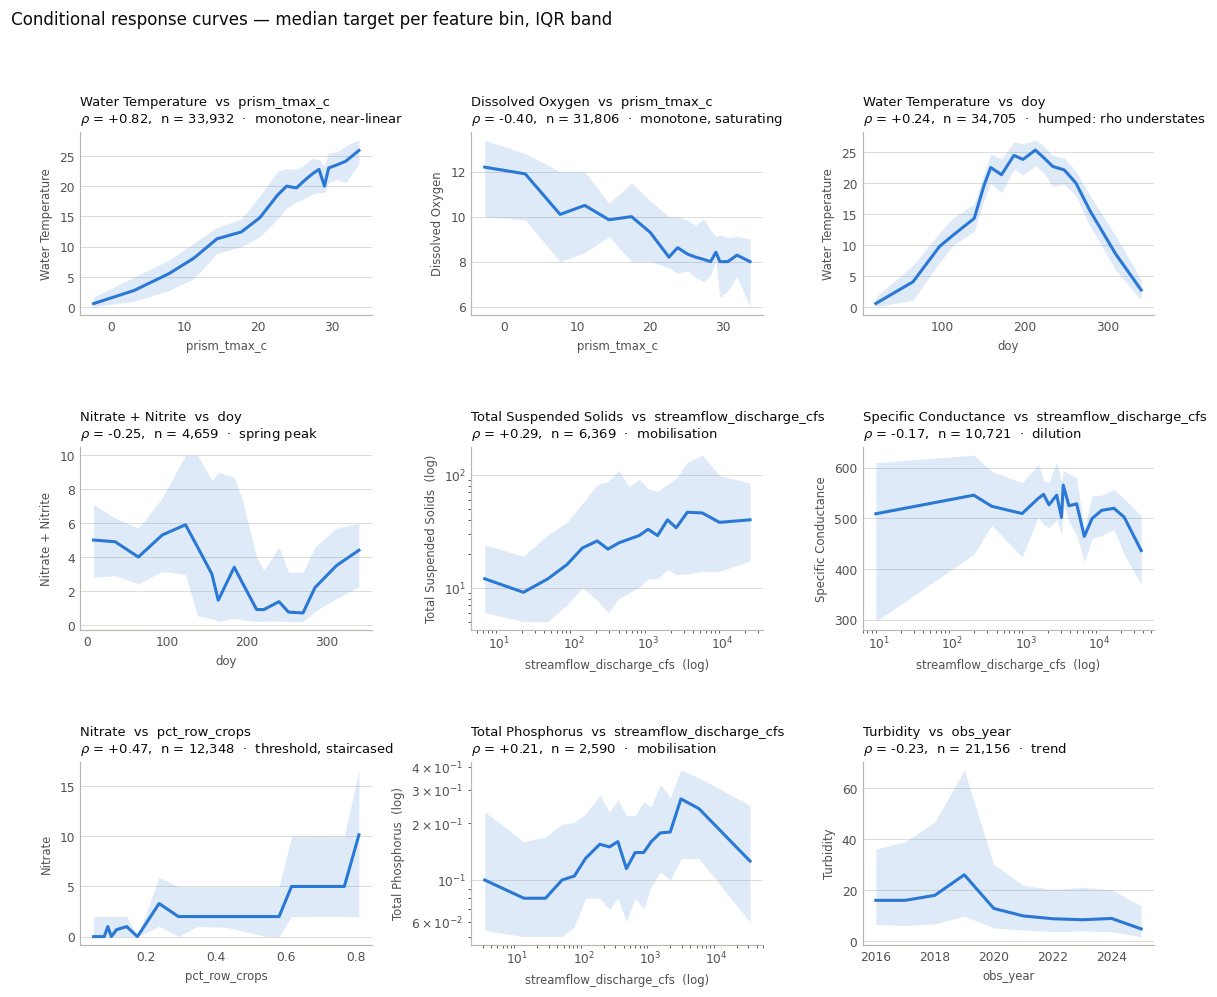

In [22]:
def response_curve(ax, xcol, tlabel, bins=18, logx=False, logy=False, note=""):
    tcol = TARGET_COLS[tlabel]
    v = mv[[xcol, tcol]].dropna()
    rho_all = v[xcol].corr(v[tcol], method="spearman")
    if logx:
        v = v[v[xcol] > 0]                    # a log axis cannot show zero or negatives
    if len(v) < 200:
        ax.set_visible(False)
        return
    edges = np.unique(np.quantile(v[xcol], np.linspace(0, 1, bins + 1)))
    if len(edges) < 4:
        ax.set_visible(False)
        return
    b = pd.cut(v[xcol], edges, include_lowest=True)
    g = v.groupby(b, observed=True)[tcol]
    mid = v.groupby(b, observed=True)[xcol].median()
    q1, med, q3 = g.quantile(0.25), g.median(), g.quantile(0.75)
    ax.fill_between(mid, q1, q3, color=BLUE, alpha=0.15, linewidth=0, zorder=2)
    ax.plot(mid, med, color=BLUE, linewidth=2, zorder=3)
    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    style_axes(ax)
    ax.set_xlabel(xcol + ("  (log)" if logx else ""), fontsize=7.6)
    ax.set_ylabel(tlabel + ("  (log)" if logy else ""), fontsize=7.6)
    ax.set_title(f"{tlabel}  vs  {xcol}\n" r"$\rho$ = " f"{rho_all:+.2f},  n = {len(v):,}"
                 + (f"  ·  {note}" if note else ""), loc="left", fontsize=8.6)


PANELS = [
    # xcol,                       target,                  logx,  logy,  note
    ("prism_tmax_c",             "Water Temperature",      False, False, "monotone, near-linear"),
    ("prism_tmax_c",             "Dissolved Oxygen",       False, False, "monotone, saturating"),
    ("doy",                      "Water Temperature",      False, False, "humped: rho understates"),
    ("doy",                      "Nitrate + Nitrite",      False, False, "spring peak"),
    ("streamflow_discharge_cfs", "Total Suspended Solids", True,  True,  "mobilisation"),
    ("streamflow_discharge_cfs", "Specific Conductance",   True,  False, "dilution"),
    ("pct_row_crops",            "Nitrate",                False, False, "threshold, staircased"),
    ("streamflow_discharge_cfs", "Total Phosphorus",       True,  True,  "mobilisation"),
    ("obs_year",                 "Turbidity",              False, False, "trend"),
]
fig, axes = plt.subplots(3, 3, figsize=(12.6, 9.6),
                         gridspec_kw={"hspace": 0.72, "wspace": 0.34})
for ax, (x, t, lx, ly, note) in zip(axes.ravel(), PANELS):
    response_curve(ax, x, t, logx=lx, logy=ly, note=note)
fig.suptitle("Conditional response curves — median target per feature bin, IQR band",
             x=0.075, ha="left", fontsize=11, y=0.995)
plt.show()

## 6. Where does the correlation live?

This is the most consequential section in the notebook.

Every correlation above pools two completely different comparisons:

- **Between stations** — *sites with more row crop upstream have higher nitrate than sites
  with less.* A cross-sectional, spatial contrast.
- **Within a station** — *this site's nitrate is higher on days when discharge is higher.*
  A temporal, response contrast.

They can differ in size and even in **sign** (Simpson's paradox). They also have completely
different consequences for the dashboard, whose entire purpose is to vary the *date* at a
*fixed* station:

> A target–feature relationship that is purely **between-station** tells you nothing about
> what happens at a given site on a given day. It is a map, not a forecast.

The decomposition: rank-transform both variables, split each into a station mean and a
deviation from that mean, then correlate the station means against each other (**between**)
and the deviations against each other (**within**). Only stations with ≥ 5 observations of
the target are used, so the within term is estimated on real repeat visits.

In [23]:
MIN_OBS = 5

def decompose(tcol, feats=FEATURE_COLS, min_obs=MIN_OBS):
    """Split target-feature Spearman correlation into between- and within-station parts."""
    v = mv[[ID_COL, tcol] + feats].dropna(subset=[tcol])
    v = v[v.groupby(ID_COL)[tcol].transform("size") >= min_obs]
    if len(v) < 200:
        return None
    ranks = v[[tcol] + feats].rank()
    grp = ranks.groupby(v[ID_COL].to_numpy())
    station_means = grp.mean()
    within = ranks - grp.transform("mean")
    out = pd.DataFrame({
        "overall": ranks.corr()[tcol],
        "between": station_means.corr()[tcol],
        "within": within.corr()[tcol],
    }).drop(index=tcol)
    # A feature that never changes at a station has no within-station variation, so the
    # within term is undefined rather than zero — worth distinguishing.
    out["station_invariant"] = within[feats].std().reindex(out.index) < 1e-9
    out["n_rows"] = len(v)
    out["n_stations"] = len(station_means)
    return out


rows = []
for tlabel, tcol in TARGET_COLS.items():
    d = decompose(tcol)
    if d is None:
        continue
    d = d.reset_index().rename(columns={"index": "feature"})
    d.insert(0, "target", tlabel)
    rows.append(d)
bw = pd.concat(rows, ignore_index=True)
bw["between_dominant"] = bw["between"].abs() > 2 * bw["within"].abs()
bw["sign_flip"] = (np.sign(bw["between"]) != np.sign(bw["within"])) & \
                  (bw["between"].abs() > 0.1) & (bw["within"].abs() > 0.1)
bw.to_csv(OUT_DIR / "mv_between_within_station.csv", index=False)

inv_feats = sorted(bw.loc[bw["station_invariant"], "feature"].unique())
print(f"{len(bw)} target x feature pairs decomposed "
      f"({bw['n_stations'].min():,}-{bw['n_stations'].max():,} stations per target)")
print(f"features that never change at a station   : {len(inv_feats)} of 30 -> "
      f"their correlation is 100% between-station by construction")
print(f"  {', '.join(inv_feats)}")
print(f"pairs where |between| > 2 x |within|      : {int(bw['between_dominant'].sum())} "
      f"({100 * bw['between_dominant'].mean():.0f}%)")
print(f"pairs whose sign flips between the two    : {int(bw['sign_flip'].sum())}")
print("\nLargest sign flips (Simpson's paradox):")
print(bw[bw["sign_flip"]].assign(swing=lambda d: (d["between"] - d["within"]).abs())
      .nlargest(10, "swing")[["target", "feature", "overall", "between", "within"]]
      .to_string(index=False, float_format=lambda v: f"{v:+.3f}"))

360 target x feature pairs decomposed (142-635 stations per target)
features that never change at a station   : 6 of 30 -> their correlation is 100% between-station by construction
  LatitudeMeasure, LongitudeMeasure, awc_mean, distance_to_climate_station_km, distance_to_streamflow_gauge_km, ksat_mean
pairs where |between| > 2 x |within|      : 145 (40%)
pairs whose sign flips between the two    : 32

Largest sign flips (Simpson's paradox):
                target                  feature  overall  between  within
Total Suspended Solids           prism_tdmean_c   +0.123   -0.387  +0.394
Total Suspended Solids             prism_tmin_c   +0.120   -0.383  +0.387
Total Suspended Solids           isu_min_feel_c   +0.107   -0.364  +0.368
Total Suspended Solids             prism_tmax_c   +0.112   -0.371  +0.344
Total Suspended Solids                  doy_cos   -0.120   +0.321  -0.390
Total Suspended Solids           isu_max_feel_c   +0.083   -0.377  +0.326
     Nitrate + Nitrite               

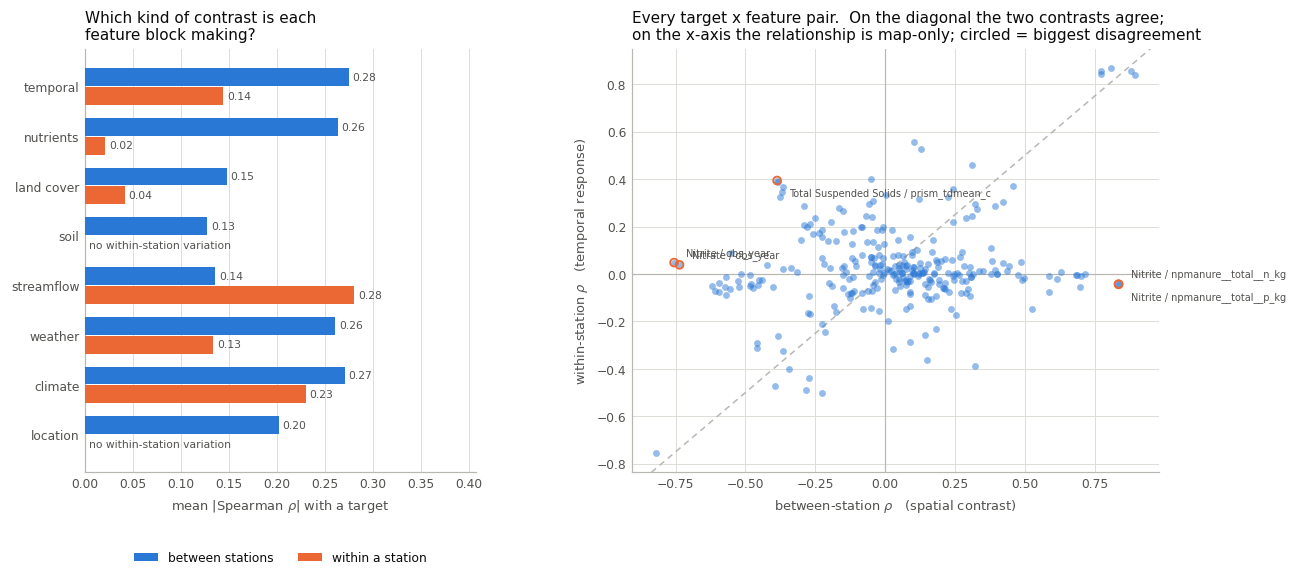

In [24]:
# Per-feature-block summary: is this block a spatial contrast or a temporal response?
blk = bw.assign(block=bw["feature"].map(FEATURE_BLOCK))
agg = (blk.groupby("block")[["between", "within"]].apply(lambda d: d.abs().mean())
       .reindex(BLOCK_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.0),
                         gridspec_kw={"width_ratios": [1, 1.35], "wspace": 0.34})

ax = axes[0]
y = np.arange(len(agg))
h = 0.36
ax.barh(y + h / 2 + 0.01, agg["between"].fillna(0), height=h, color=BLUE, zorder=3,
        label="between stations")
ax.barh(y - h / 2 - 0.01, agg["within"].fillna(0), height=h, color=ORANGE, zorder=3,
        label="within a station")
for i, (b, w) in enumerate(zip(agg["between"], agg["within"])):
    ax.text(b + 0.004, i + h / 2 + 0.01, f"{b:.2f}", va="center", fontsize=7, color=INK_SOFT)
    # A whole block can be station-invariant, in which case there is no within term at all.
    ax.text(0.004 if pd.isna(w) else w + 0.004, i - h / 2 - 0.01,
            "no within-station variation" if pd.isna(w) else f"{w:.2f}",
            va="center", fontsize=7, color=INK_SOFT)
ax.set_yticks(y); ax.set_yticklabels(agg.index, fontsize=8)
style_axes(ax, axis="x")
ax.set_xlim(0, float(np.nanmax(agg.to_numpy())) * 1.45)
ax.set_xlabel(r"mean |Spearman $\rho$| with a target")
ax.set_title("Which kind of contrast is each\nfeature block making?", loc="left")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)

ax = axes[1]
sc = bw.dropna(subset=["between", "within"])
ax.scatter(sc["between"], sc["within"], s=20, color=BLUE, alpha=0.5, linewidths=0, zorder=3)
ax.axline((0, 0), slope=1, color=AXISLINE, linewidth=1, linestyle=(0, (4, 3)), zorder=2)
ax.axhline(0, color=AXISLINE, linewidth=0.8, zorder=2)
ax.axvline(0, color=AXISLINE, linewidth=0.8, zorder=2)

# Direct-label the pairs where the two contrasts disagree most — identity by label, not
# by an eight-way palette a scatter cannot separate.
lab = sc.assign(swing=(sc["between"] - sc["within"]).abs()).nlargest(5, "swing")
for k, (_, r) in enumerate(lab.iterrows()):
    dx, dy = (8, 5) if k % 2 == 0 else (8, -10)
    ax.annotate(f"{r['target']} / {r['feature']}", (r["between"], r["within"]),
                textcoords="offset points", xytext=(dx, dy), fontsize=6.4, color=INK_SOFT)
ax.scatter(lab["between"], lab["within"], s=26, facecolor="none", edgecolor=ORANGE,
           linewidth=1.2, zorder=4)
style_axes(ax, axis="both")
ax.set_xlabel(r"between-station $\rho$   (spatial contrast)")
ax.set_ylabel(r"within-station $\rho$   (temporal response)")
ax.set_title("Every target x feature pair.  On the diagonal the two contrasts agree;\n"
             "on the x-axis the relationship is map-only; circled = biggest disagreement",
             loc="left")
plt.show()

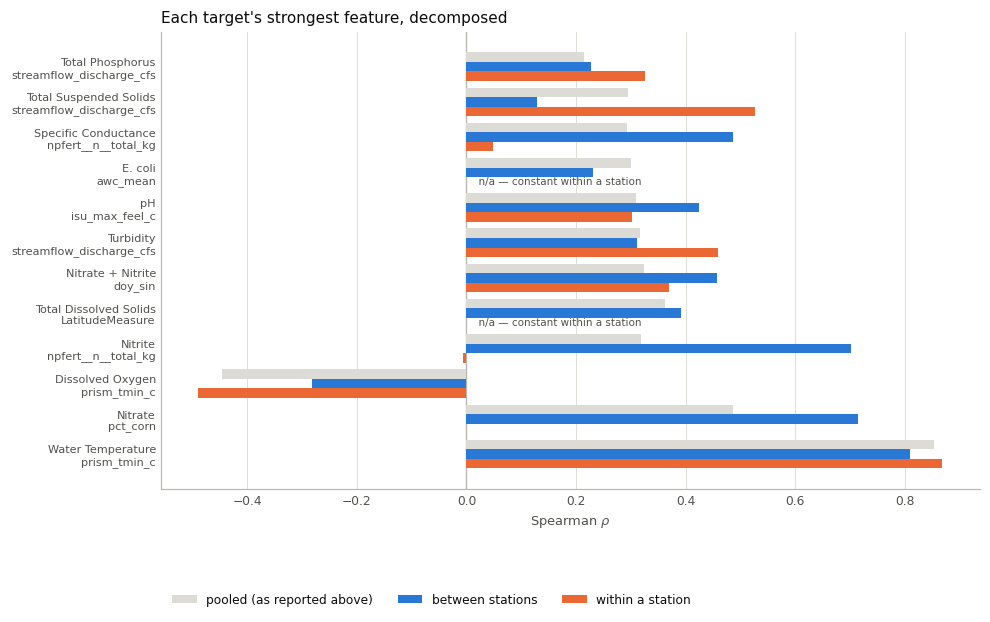

                                         feature  overall  between  within  n_rows  n_stations
Water Temperature                   prism_tmin_c   +0.852   +0.809  +0.868   34019         622
Nitrate                                 pct_corn   +0.486   +0.714  -0.001   12175         173
Dissolved Oxygen                    prism_tmin_c   -0.445   -0.282  -0.489   31224         586
Nitrite                      npfert__n__total_kg   +0.318   +0.702  -0.007   11468         142
Total Dissolved Solids           LatitudeMeasure   +0.361   +0.392     NaN   17542         325
Nitrate + Nitrite                        doy_sin   +0.323   +0.457  +0.370    4373         248
Turbidity               streamflow_discharge_cfs   +0.316   +0.311  +0.459   20545         484
pH                                isu_max_feel_c   +0.310   +0.423  +0.302   31506         635
E. coli                                 awc_mean   +0.300   +0.231     NaN   15602         305
Specific Conductance         npfert__n__total_kg  

In [25]:
# The same split, target by target, for the feature each target correlates with most.
pick = (bw.assign(a=bw["overall"].abs()).sort_values("a", ascending=False)
        .groupby("target").head(1).set_index("target").reindex(row_max.index).dropna(subset=["overall"]))

fig, ax = plt.subplots(figsize=(9.6, 5.4))
y = np.arange(len(pick))
h = 0.27
ax.barh(y + h, pick["overall"], height=h, color=GRIDLINE, zorder=3, label="pooled (as reported above)")
ax.barh(y, pick["between"], height=h, color=BLUE, zorder=3, label="between stations")
ax.barh(y - h, pick["within"].fillna(0), height=h, color=ORANGE, zorder=3,
        label="within a station")
ax.axvline(0, color=AXISLINE, linewidth=0.9, zorder=2)
for i, (w, inv) in enumerate(zip(pick["within"], pick["station_invariant"])):
    if pd.isna(w):
        ax.text(0.01, i - h, "  n/a — constant within a station", va="center",
                fontsize=6.8, color=INK_SOFT)
ax.set_yticks(y)
ax.set_yticklabels([f"{t}\n{f}" for t, f in zip(pick.index, pick["feature"])], fontsize=7.4)
style_axes(ax, axis="x")
ax.set_xlabel(r"Spearman $\rho$")
ax.set_title("Each target's strongest feature, decomposed", loc="left")
ax.legend(fontsize=8, loc="lower left", bbox_to_anchor=(0.0, -0.28), ncol=3)
plt.show()

print(pick[["feature", "overall", "between", "within", "n_rows", "n_stations"]]
      .to_string(float_format=lambda v: f"{v:+.3f}"))

## 7. Is it real, or is it season?

Day-of-year drives almost everything in a temperate river: temperature, discharge, fertiliser
application, biological activity, and the sampling schedule itself. Any two variables that
both follow the calendar will correlate with each other whether or not one affects the other.

**Partial correlation** removes that shared driver. Both variables are rank-transformed and
regressed on the seasonal basis (`doy_sin`, `doy_cos`, `obs_year`); the correlation of what
is left over is the association that is *not* explained by the calendar.

The interesting quantity is the **attenuation** — how much of the raw correlation survives.
A relationship that collapses toward zero was season all along.

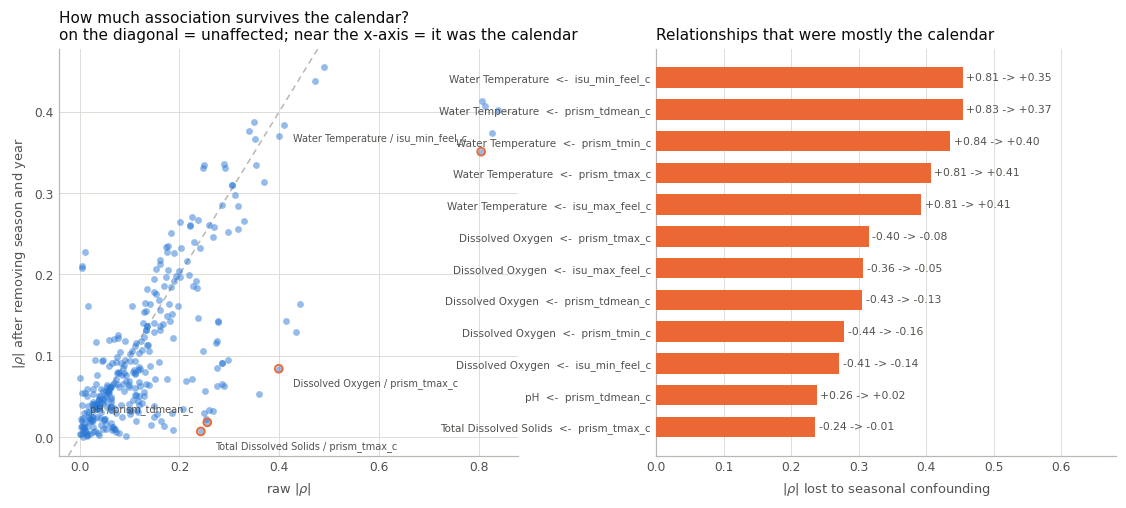

of 106 pairs with raw |rho| >= 0.15, 35 lose more than half their association once season and year are removed.


In [26]:
CTRL = ["doy_sin", "doy_cos", "obs_year"]

def partial_block(tcol, feats, ctrl=CTRL):
    """Rank-partial correlation of a target with each feature, controlling for `ctrl`."""
    cols = [tcol] + [f for f in feats if f not in ctrl]
    v = mv[cols + ctrl].dropna(subset=[tcol])
    if len(v) < 200:
        return None
    ranks = v[cols].rank()
    ranks = ranks.fillna(ranks.median())            # median-impute, as the pipeline does
    Z = np.column_stack([np.ones(len(v))] + [v[c].to_numpy(float) for c in ctrl])
    Z = np.nan_to_num(Z, nan=0.0)
    beta, *_ = np.linalg.lstsq(Z, ranks.to_numpy(float), rcond=None)
    resid = pd.DataFrame(ranks.to_numpy(float) - Z @ beta, columns=cols)
    raw = ranks.corr()[tcol].drop(index=tcol)
    par = resid.corr()[tcol].drop(index=tcol)
    return pd.DataFrame({"raw": raw, "partial": par, "n": len(v)})


prows = []
for tlabel, tcol in TARGET_COLS.items():
    p = partial_block(tcol, FEATURE_COLS)
    if p is None:
        continue
    p = p.reset_index().rename(columns={"index": "feature"})
    p.insert(0, "target", tlabel)
    prows.append(p)
pc = pd.concat(prows, ignore_index=True)
pc["retained"] = np.where(pc["raw"].abs() > 0.05, pc["partial"].abs() / pc["raw"].abs(), np.nan)
pc.to_csv(OUT_DIR / "mv_partial_correlation_season.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8), gridspec_kw={"wspace": 0.3})

ax = axes[0]
ax.axline((0, 0), slope=1, color=AXISLINE, linewidth=1, linestyle=(0, (4, 3)), zorder=2)
ax.scatter(pc["raw"].abs(), pc["partial"].abs(), s=20, color=BLUE, alpha=0.5,
           linewidths=0, zorder=3)
# One label per target, not per pair: the five biggest losses are all Water Temperature
# against five near-identical thermal features, and would stack on one spot.
big0 = (pc.assign(lost=pc["raw"].abs() - pc["partial"].abs())
        .sort_values("lost", ascending=False).groupby("target").head(1).nlargest(4, "lost"))
for k, (_, r) in enumerate(big0.iterrows()):
    dx, dy = (-9, 7) if k % 2 == 0 else (9, -11)
    ax.annotate(f"{r['target']} / {r['feature']}", (abs(r["raw"]), abs(r["partial"])),
                textcoords="offset points", xytext=(dx, dy), fontsize=6.4, color=INK_SOFT,
                ha="right" if dx < 0 else "left")
ax.scatter(big0["raw"].abs(), big0["partial"].abs(), s=26, facecolor="none",
           edgecolor=ORANGE, linewidth=1.2, zorder=4)
style_axes(ax, axis="both")
ax.set_xlabel(r"raw |$\rho$|")
ax.set_ylabel(r"|$\rho$| after removing season and year")
ax.set_title("How much association survives the calendar?\n"
             "on the diagonal = unaffected; near the x-axis = it was the calendar",
             loc="left")

ax = axes[1]
big = pc[pc["raw"].abs() >= 0.15].copy()
big["lost"] = big["raw"].abs() - big["partial"].abs()
worst = big.nlargest(12, "lost").sort_values("lost")
ax.barh(worst["target"] + "  <-  " + worst["feature"], worst["lost"], color=ORANGE,
        height=0.64, zorder=3)
for y, (l, r, p) in enumerate(zip(worst["lost"], worst["raw"], worst["partial"])):
    ax.text(l + 0.005, y, f"{r:+.2f} -> {p:+.2f}", va="center", fontsize=7, color=INK_SOFT)
style_axes(ax, axis="x")
ax.set_xlim(0, worst["lost"].max() * 1.5)
ax.set_xlabel(r"|$\rho$| lost to seasonal confounding")
ax.set_title("Relationships that were mostly the calendar", loc="left")
ax.tick_params(axis="y", labelsize=6.8)
plt.show()

sub = pc[pc["raw"].abs() >= 0.15]
print(f"of {len(sub)} pairs with raw |rho| >= 0.15, "
      f"{int((sub['retained'] < 0.5).sum())} lose more than half their association "
      f"once season and year are removed.")

## 8. The land-cover block — a formula, not a measurement

Land-cover shares are **compositional data**: they are proportions of one watershed, bound
to sum to a constant. That has two consequences no amount of extra data fixes.

1. Compositional variables are **forced** to correlate negatively — if corn's share goes up,
   something else's must come down. A negative ρ between two shares is partly the constraint
   talking, not an ecological finding.
2. If one column is a **sum of others**, the design matrix is exactly rank-deficient — that
   column carries no information whatsoever, and a linear model's coefficients on the group
   are not identified.

§2.4 found a genuinely zero eigenvalue and named the direction. This section confirms it
against the raw columns.

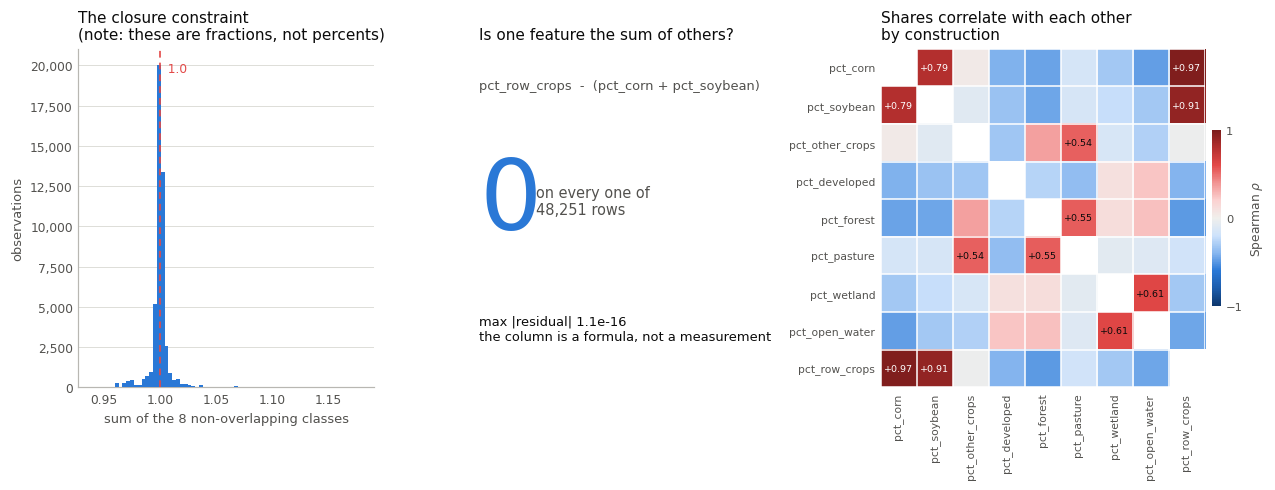

sum of the 8 non-overlapping classes: median 0.9998   1st-99th pct 0.9671 - 1.0374
  -> the pct_ columns are FRACTIONS in [0, 1], despite the 'pct_' name (pct_corn mean = 0.263 = 26.3%)

pct_row_crops - (pct_corn + pct_soybean): max |residual| 1.110e-16 over 48,251 rows
  exactly equal on 100.00% of rows -> an EXACT linear dependency inside FEATURE_COLS

eigenvalues of the corr matrix of ['pct_corn', 'pct_soybean', 'pct_row_crops']: [-0.          0.23182514  2.76817486]
  rank 2 / 3 -> one of the three is redundant


In [27]:
PCT_ALL = [c for c in df.columns if c.startswith("pct_")]
pcts = df[PCT_ALL].apply(pd.to_numeric, errors="coerce")

# pct_row_crops is an aggregate of two of the other classes, so it must be excluded from
# any closure test - otherwise its area is counted twice.
PCT_PARTS = [c for c in PCT_ALL if c != "pct_row_crops"]
part_sum = pcts[PCT_PARTS].sum(axis=1, min_count=len(PCT_PARTS))

resid = (pcts["pct_row_crops"] - pcts[["pct_corn", "pct_soybean"]].sum(axis=1)).dropna()

fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.0),
                         gridspec_kw={"wspace": 0.34, "width_ratios": [1, 1, 1.15]})

ax = axes[0]
ax.hist(part_sum.dropna(), bins=70, color=BLUE, zorder=3)
ax.axvline(1.0, color=RED, linewidth=1.1, linestyle=(0, (4, 3)), zorder=4)
ax.text(1.0, ax.get_ylim()[1] * 0.96, "  1.0", fontsize=8, color=RED, va="top")
style_axes(ax); thousands(ax)
ax.set_xlabel(f"sum of the {len(PCT_PARTS)} non-overlapping classes")
ax.set_ylabel("observations")
ax.set_title("The closure constraint\n(note: these are fractions, not percents)", loc="left")

ax = axes[1]
# A histogram of a quantity that is exactly zero on every row is not a chart - it is one
# number. Show the number.
ax.axis("off")
ax.text(0, 0.88, "pct_row_crops  -  (pct_corn + pct_soybean)", fontsize=8.5,
        color=INK_SOFT, transform=ax.transAxes)
ax.text(0, 0.55, "0", fontsize=64, color=BLUE, transform=ax.transAxes, va="center")
ax.text(0.19, 0.55, f"on every one of\n{len(resid):,} rows", fontsize=9.5,
        color=INK_SOFT, transform=ax.transAxes, va="center")
ax.text(0, 0.14, f"max |residual| {resid.abs().max():.1e}\n"
                 "the column is a formula, not a measurement",
        fontsize=8.5, color=INK, transform=ax.transAxes)
ax.set_title("Is one feature the sum of others?", loc="left")

ax = axes[2]
lc_corr = pcts[PCT_ALL].corr(method="spearman")
im = heatmap(lc_corr, ax, annot_at=0.5, fontsize=7, mask_diagonal=True)
add_colorbar(fig, im, ax, r"Spearman $\rho$", ticks=[-1, 0, 1])
ax.set_title("Shares correlate with each other\nby construction", loc="left")
plt.show()

print(f"sum of the {len(PCT_PARTS)} non-overlapping classes: median {part_sum.median():.4f}   "
      f"1st-99th pct {part_sum.quantile(0.01):.4f} - {part_sum.quantile(0.99):.4f}")
print(f"  -> the pct_ columns are FRACTIONS in [0, 1], despite the 'pct_' name "
      f"(pct_corn mean = {pcts['pct_corn'].mean():.3f} = {100 * pcts['pct_corn'].mean():.1f}%)")
print(f"\npct_row_crops - (pct_corn + pct_soybean): "
      f"max |residual| {resid.abs().max():.3e} over {len(resid):,} rows")
print(f"  exactly equal on {100 * (resid.abs() < 1e-12).mean():.2f}% of rows "
      f"-> an EXACT linear dependency inside FEATURE_COLS")

# The three land-cover shares in the feature set, on their own.
lc_feats = ["pct_corn", "pct_soybean", "pct_row_crops"]
ev = np.linalg.eigvalsh(X_std[lc_feats].corr().to_numpy())
print(f"\neigenvalues of the corr matrix of {lc_feats}: {np.round(ev, 12)}")
print(f"  rank {np.linalg.matrix_rank(X_std[lc_feats].corr().to_numpy(), tol=1e-10)} / 3 "
      f"-> one of the three is redundant")

## 9. Findings

### Method

- Ranks matter. Across the 360 target × feature pairs, the median |Pearson r| is **0.062**
  against a median |Spearman ρ| of **0.111** — switching to ranks nearly doubles the typical
  measured association. **29%** of pairs gain more than 0.05, only 7% lose that much. The
  extreme case is `Nitrite ← npfert__n__total_kg`: **r = +0.011, ρ = +0.353**. On the raw
  scale that relationship is invisible; the heavy tails documented in the univariate
  notebook are what hides it.
- Co-measurement is uneven and must be checked before any target–target number is read. The
  median target pair shares 6,228 rows, but **8 of 144 pairs share fewer than 200**, and two
  pairs — Nitrite with Nitrate + Nitrite, and Nitrite with Total Phosphorus — share
  **zero rows**. They are measured by different programs that never overlap.

### Feature ↔ feature: 30 columns, far fewer facts

- **21 pairs exceed |ρ| = 0.70 and 5 exceed 0.95.** The worst are near-duplicates:
  manure N ↔ manure P **0.987**, fertiliser N ↔ fertiliser P **0.977**, `pct_corn` ↔
  `pct_row_crops` **0.970**, `prism_tmin_c` ↔ `isu_min_feel_c` **0.955** (two agencies
  measuring the same air).
- Clustering at |ρ| ≥ 0.65 collapses the 30 columns into **19 groups**, dominated by one
  six-member thermal cluster — `prism_tmax_c`, `prism_tmin_c`, `prism_tdmean_c`,
  `isu_max_feel_c`, `isu_min_feel_c` and `doy_cos` are, statistically, one variable.
- **Eight features have VIF ≥ 10.** The four nutrient-budget columns are the worst
  (**61.3, 57.1, 55.8, 54.6**) — four columns carrying roughly two dimensions — followed by
  `prism_tmin_c` (26.2) and `prism_tdmean_c` (21.9).
- **The correlation matrix is singular: rank 29 of 30**, condition number infinite. The null
  direction is unambiguous — `+0.795·pct_row_crops − 0.502·pct_corn − 0.340·pct_soybean`,
  which is §8's exact identity in standardised units.
- PCA confirms the scale of the redundancy: **PC1 alone carries 19.7%** where independent
  features would give 3.3%, and **15 components reach 90%** of the variance where 27 would
  be needed if the columns were independent. PC1 is the thermal axis, PC2 is temperature
  against corn share (a north–south agricultural gradient), PC3 is developed land against
  soil conductivity and discharge, PC4 is day-of-year.
- The joint distribution is far from multivariate normal: **5.36% of rows** exceed the
  χ²(30) 99.9% cut where 0.1% is expected, and the largest Mahalanobis D² is **2,802**
  against a cut of 58.3.

### Target ↔ target: 12 problems, not 12 independent ones

- **Specific Conductance and Total Dissolved Solids correlate at ρ = 0.984** on 9,285 shared
  rows. These are not two targets; TDS is conventionally estimated *from* conductance. Total
  Suspended Solids and Turbidity follow at **0.873** — also two measurements of one physical
  property (particles in the water).
- Beyond those two pairs the structure is loose: the next strongest is Total Phosphorus ↔
  Total Suspended Solids at 0.577 (phosphorus travels bound to sediment), then a nutrient ↔
  dissolved-solids group in the 0.52–0.56 range.
- **Three of the strongest apparent relationships rest on thin overlaps** — Nitrate ↔ TDS
  (ρ = 0.556) on **816** rows, Nitrate + Nitrite ↔ Specific Conductance (0.518) on 1,697,
  Nitrite ↔ Turbidity (0.361) on 748.

### Target ↔ feature: the signal is weak, and it is spatial

- **Only one target has a feature above |ρ| = 0.5**: Water Temperature ← `prism_tmin_c` at
  **+0.849**, which is a genuine physical mechanism (air heats water). Nitrate ← `pct_corn`
  at +0.489 is second. **The other ten targets top out between 0.209 and 0.442.**
- Compared against the reported random-forest R², the gap is enormous for the
  best-scoring targets: Specific Conductance has a best-single-feature ρ² of **0.084**
  against a reported **R² = 0.886**; Total Dissolved Solids, 0.124 against 0.824. Water
  Temperature — the one target with a real mechanism in the feature set — has the *smallest*
  gap (0.721 → 0.952). **The models score highest exactly where the correlation structure
  supports it least.** §5.1 and §6 identify what fills that gap.

### Linear vs. non-linear — and what the extra dependence really is

- Mutual information reports far more dependence than Spearman on **317 of 360** pairs, and
  the permutation null accounts for only **1%** of the raw estimate, so this is not
  estimator bias.
- But it is not mechanism either. The eight features with the highest MI-implied dependence
  are `LatitudeMeasure`, `LongitudeMeasure`, the two gauge-distance columns and the four
  nutrient-budget columns — **every one of which has between-station variance share ≥ 0.987**,
  and the top four sit at exactly 1.000 with ~0.99 distinct values per station. The clearest
  case is `Specific Conductance ← LongitudeMeasure`: **|ρ| = 0.001, MI-implied r_equiv = 0.94**.
  Longitude is not a mechanism for conductance; it is an address. The rank correlation
  between "how well a feature identifies the station" and "how much MI it carries" is
  **+0.582**.
- At the other end, `isu_snow_in` and `isu_snowd_in` carry essentially nothing
  (r_equiv ≈ 0.05) — they are zero on most rows year-round.
- Shape matters where the mechanism is real: water temperature against day-of-year is a
  clean inverted U that Spearman scores at only +0.24, while against `prism_tmax_c` — the
  same seasonal signal, monotonically encoded — it scores +0.82.

### Where the correlation lives

- **Six of the 30 features never change at a station** (`LatitudeMeasure`,
  `LongitudeMeasure`, `awc_mean`, `ksat_mean`, and both distance-to-gauge columns). For
  these, 100% of their correlation with any target is between-station by construction.
- Overall, **mean |between-station ρ| is 0.225 against mean |within-station ρ| of 0.120**,
  and **145 of 360 pairs (40%)** have a between term more than twice the within term.
- The block pattern is stark. **Nutrients: between 0.26, within 0.02. Land cover: 0.15 vs
  0.04.** These are maps, not responses. The single exception is **streamflow — between
  0.14, within 0.28** — the only block that tells you more about a given day than about a
  given place.
- Two headline relationships are almost purely spatial: **Nitrate ← `pct_corn`** is +0.714
  between stations and **−0.001 within** one; **Nitrite ← `npfert__n__total_kg`** is +0.702
  between and **−0.007 within**. Sites in corn country have more nitrate; a site's nitrate
  on a given day has nothing to do with its corn share.
- **32 pairs flip sign** between the two contrasts (Simpson's paradox). Total Suspended
  Solids ← `prism_tdmean_c` is −0.387 between stations but **+0.394 within** one: cooler
  regions have muddier rivers, yet any given river is muddier on warm days. Specific
  Conductance ← discharge is +0.150 between but **−0.364 within** — the dilution effect is
  only visible once you stop comparing different rivers.
- Where a mechanism is real, both contrasts agree: Water Temperature ← `prism_tmin_c` is
  +0.809 between and **+0.868 within**.

### Season as a confounder

- Of the 106 pairs with raw |ρ| ≥ 0.15, **35 lose more than half** their association once
  `doy_sin`, `doy_cos` and `obs_year` are partialled out.
- The thermal block takes the biggest hit: Water Temperature ← `isu_min_feel_c` falls
  **+0.805 → +0.351**, and Dissolved Oxygen ← `prism_tmax_c` falls **−0.399 → −0.084**
  (21% retained) — DO's apparent temperature dependence is substantially the calendar.
- The spatial features are untouched, as expected — Specific Conductance ←
  `npfert__p__total_kg` actually *strengthens* (+0.290 → +0.335), because removing seasonal
  noise sharpens a purely cross-sectional contrast.

### The land-cover block

- The eight non-overlapping land-cover classes sum to **0.9998** at the median: the columns
  are **fractions in [0, 1], not percentages**, despite the `pct_` prefix (`pct_corn` averages
  0.263 = 26.3%).
- **`pct_row_crops` = `pct_corn` + `pct_soybean` exactly** — residual 0 on all 48,251 rows,
  max |residual| 1.1e-16. It is a formula, not a measurement, and it is the source of the
  rank deficiency in §2.4.

## 10. Red flags

Seven issues, ordered by severity. Flags 1, 3 and 4 are new measurements of problems the
univariate notebook flagged from a different angle; 2, 5, 6 and 7 are new.

| # | Red flag | Severity | Where |
|---|----------|----------|-------|
| 1 | Model skill comes from station identity, not from these relationships | **critical** | training notebooks |
| 2 | `pct_row_crops` is an exact sum of two other features — the design matrix is singular | **critical** | `FEATURE_COLS` |
| 3 | 40% of target–feature relationships are spatial-only, so the date control has nothing to act on | **critical** | `app.py` |
| 4 | The nutrient block is four columns of two dimensions, all of it between-station | **high** | `FEATURE_COLS` |
| 5 | Specific Conductance and TDS are one target modelled twice (ρ = 0.984) | medium | targets |
| 6 | Half the thermal signal is the calendar, and the calendar is already a feature | medium | interpretation |
| 7 | Three target–target correlations rest on fewer than 2,000 shared rows | medium | data |

**1. The models are scoring on station identity (critical).**
For Specific Conductance, the best single feature explains **8.4%** of the variance
(ρ² = 0.084) while the reported random-forest R² is **0.886** — a gap of 0.80 that no
combination of these weak, mutually-redundant correlations can plausibly fill. §5.1 shows
what does fill it: `LongitudeMeasure` has |ρ| = 0.001 with conductance but an MI-implied
dependence of **0.94**, because with ~1,326 distinct values across 1,345 stations it *is* a
station identifier, and station identity predicts conductance well. Combined with the
univariate notebook's finding that 99.1–99.7% of test rows sit at a station also present in
training, the reported R² for the station-determined targets is measuring recall, not
prediction. **Fix:** re-split with `GroupKFold` grouped on `MonitoringLocationIdentifier`
and re-report; expect Specific Conductance and TDS to fall hardest. If per-station
prediction is the actual goal, drop the coordinate features and say so explicitly, so the
model is forced to use mechanism.

**2. `pct_row_crops` makes the feature matrix singular (critical).**
It equals `pct_corn + pct_soybean` exactly on every one of 48,251 rows. The 30-feature
correlation matrix therefore has rank 29 and a genuinely zero eigenvalue. For the linear
regression this means the coefficients on those three columns are **not identified** — the
solver returns one of infinitely many equivalent answers, and any interpretation of those
three coefficients (including their sign) is meaningless. The tree models are unaffected in
accuracy but split their importance arbitrarily across the trio. **Fix:** drop
`pct_row_crops` from `FEATURE_COLS` in `app.py` and in all three training notebooks. It
adds nothing; the information is fully present in the other two. Note this changes the
feature contract, so the `.pkl` files must be retrained together.

**3. Most of the signal cannot respond to the date the user picks (critical).**
The dashboard's premise is that changing the prediction date changes the prediction. But
40% of target–feature relationships have a between-station term more than twice the within-
station term, and six features have **no** within-station variation at all. Nitrate ←
`pct_corn` is +0.714 across sites and **−0.001** within one. So for a fixed station, the
features that carry the most correlation are constant, and the ones that do vary with date
(the weather block) are — per the univariate notebook — frozen at the station's last visit
anyway. The date control moves `doy`/`obs_year` and nothing else. **Fix:** this is the same
underlying defect as univariate red flag 2, and the same remedy applies (serve date-matched
weather, or drop the pretence of temporal variation). What this notebook adds is the
measurement of how little would be left: the streamflow block is the only one whose
within-station association (0.28) exceeds its between-station association (0.14).

**4. The nutrient-budget block is four columns of about two facts (high).**
`npfert__n__total_kg`, `npfert__p__total_kg`, `npmanure__total__n_kg` and
`npmanure__total__p_kg` have VIFs of 61.3, 54.6, 57.1 and 55.8; the N and P members
correlate at 0.977 and 0.987. On top of that, their target association is essentially
100% between-station (block mean: between 0.26, within 0.02) and the univariate notebook
found them up to 8 years stale. **Fix:** keep one N and one P column, or replace the four
with their first two principal components. This will not change accuracy much but will make
feature importances readable for the first time.

**5. Specific Conductance and Total Dissolved Solids are one target (medium).**
ρ = 0.984 over 9,285 co-measured rows — TDS is conventionally *derived* from conductance by
a linear factor. Training and reporting them as two independent successes double-counts a
single result, and both are in the group whose scores flag 1 puts in question. **Fix:**
report them as one, or state the relationship explicitly wherever both appear.

**6. The temperature features and the seasonal features are the same signal (medium).**
Water Temperature ← `isu_min_feel_c` falls from +0.805 to +0.351 once day-of-year is
partialled out, and Dissolved Oxygen ← `prism_tmax_c` collapses from −0.399 to −0.084. The
thermal cluster and `doy_cos` sit in one cluster at |ρ| ≥ 0.65. This is not wrong — season
*is* the mechanism — but it means the apparent independent contribution of the weather block
is roughly half what the raw correlations suggest, and importance attributed to either is
arbitrary between them.

**7. Some target–target correlations are computed on very few rows (medium).**
Nitrate ↔ TDS (ρ = 0.556) rests on **816** shared rows out of 48,251; Nitrite ↔ Turbidity
(0.361) on 748. Two pairs share **zero** rows and are structurally uncorrelatable. **Fix:**
never impute one target from another, and carry the shared-row count wherever these
correlations are quoted — `outputs/mv_target_pairs.csv` has it in a column.

### What this notebook does *not* establish

Correlation here is descriptive. None of these numbers identify causal effects: the
between-station contrasts are confounded by everything else that varies geographically
(soil, geology, point sources, sampling programme), and the within-station contrasts are
confounded by season, which §7 only partially removes. The between/within split narrows
what a relationship *could* mean; it does not settle it.

### Files written

| File | Contents |
|---|---|
| `outputs/mv_pearson_vs_spearman.csv` | Both coefficients and the rank-transform gain for all 360 target × feature pairs |
| `outputs/mv_feature_correlation.csv` | 30 × 30 Spearman matrix, in cluster order |
| `outputs/mv_feature_pairs.csv` | Every feature pair with \|ρ\|, source blocks, and whether they share a block |
| `outputs/mv_feature_clusters.csv` | Cluster assignment per feature at \|ρ\| ≥ 0.65 |
| `outputs/mv_vif.csv` | Variance inflation factor and source block per feature |
| `outputs/mv_null_space.csv` | The three smallest eigenvalues and their feature combinations |
| `outputs/mv_pca_loadings.csv` | PC1–PC6 loadings for all 30 features |
| `outputs/mv_target_overlap.csv` | Co-measured row count for every target pair |
| `outputs/mv_target_correlation.csv` | 12 × 12 Spearman matrix, in cluster order |
| `outputs/mv_target_pairs.csv` | Target pairs with ρ **and** the shared-row count behind it |
| `outputs/mv_target_feature_correlation.csv` | The 12 × 30 signal matrix |
| `outputs/mv_correlation_vs_model_r2.csv` | Best single-feature ρ² vs. reported random-forest R² per target |
| `outputs/mv_mutual_information.csv` | Raw MI, permutation null, excess, and r_equiv per pair |
| `outputs/mv_station_identifiability.csv` | Between-station variance share vs. mean MI per feature |
| `outputs/mv_between_within_station.csv` | Overall / between / within decomposition for all 360 pairs |
| `outputs/mv_partial_correlation_season.csv` | Raw vs. season-adjusted ρ, and the share retained |

### Next step

The two structural defects in §10 (flags 1 and 2) are cheap to fix and change what every
downstream number means, so they come before any further analysis. After that, the open
question this notebook raises but cannot answer is whether a **within-station** model — one
predicting each site's deviation from its own baseline — has any skill at all. §6 says that
is a different and much harder problem than the one the current metrics describe.